(mmm_lfo_cv_model_comparison)=
# Fast leave-future-out cross-validation for Bayesian marketing mix models

**Fast leave-future-out cross-validation for Bayesian marketing mix models** helps you compare Bayesian
marketing mix models (MMMs) by future predictive performance without refitting every candidate at every
forecast origin. The practical outcome is a leakage-aware comparison of one-week-ahead sales predictions,
with diagnostics showing when approximate updates need exact refits.

Different MMM assumptions can imply additive effects on the sales scale, multiplicative effects on the
log-sales scale, or a log-log relationship that changes how media response is interpreted. Prior assumptions
also matter when channels are correlated or weakly identified. This case study focuses on predictive
validation: it does not turn a better predictive score into a causal claim.

## At a Glance

- Compare four Bayesian MMM specifications on the same synthetic weekly sales and channel-spend data.
- Use an initial 104-week training window, one-week-ahead forecasts, and sliding pre-holdout origins.
- Reuse posterior draws with Pareto-smoothed importance sampling (PSIS), then refit exactly when the
  configured diagnostic requires it.
- Keep target and channel scaling fixed from the initial training window so future information does not
  change the model's scale between folds.
- Check the resulting predictive comparison on an untouched 26-week period that is longer than the one-week
  forecast horizon.

The candidate table makes the assumptions and their practical limits explicit:

```{list-table}
:header-rows: 1

* - Model
  - Link
  - Saturation
  - Likelihood
  - Modeling assumption
  - Practical interpretation
  - Likely failure mode
* - Additive
  - `identity`
  - `LogisticSaturation`
  - Normal
  - Media contributions add on the sales scale with approximately constant residual
    spread.
  - A unit of transformed channel activity contributes an additive amount to expected
    sales.
  - Multiplicative variance, skewed positive outcomes, or changing scale can make the
    residual model inadequate.
* - Additive, tight priors
  - `identity`
  - `LogisticSaturation`
  - Normal
  - The same additive structure is paired with deliberately restrictive priors.
  - A stress test for how a rigid prior can affect predictive validation.
  - Genuine signal outside the narrow prior support can be shrunk away; this is not a
    default production prior.
* - Log / multiplicative
  - `log`
  - `LogisticSaturation`
  - LogNormal
  - Effects combine on the log-sales scale and the outcome remains positive.
  - Channel effects are naturally read as proportional changes in expected sales.
  - Zeros or negative targets are incompatible, and additive response may be
    misrepresented.
* - Log-log
  - `log`
  - `LogSaturation`
  - LogNormal
  - A positive log-link model also uses log saturation for a more elasticity-like
    response shape.
  - Useful for testing a different diminishing-returns story for channel activity.
  - Low-spend behavior, zeros, or a mismatched response curve can make the
    interpretation unstable.
```

For more detail on the additive, log, and log-log MMM parameterizations, see the {ref}`mmm_multiplicative`
notebook.


The LFO-CV API used below is currently available from the ArviZ development branch and is not in a released
`arviz-stats` version yet. Until the synchronized release is available, run this notebook in an isolated
environment and install the required `arviz-stats` revision manually:

```bash
uv pip install --no-deps "arviz-stats @ git+https://github.com/arviz-devs/arviz-stats@3d94eba58c1cfe0210f2d9dc49ec8b382eaa3046"
```


In [1]:
"""Fast leave-future-out cross-validation for Bayesian marketing mix models."""

import hashlib
import importlib.metadata
import json
import logging
import os
import warnings
from pathlib import Path

import arviz_base
import arviz_stats
from IPython.display import display

# Temporary compatibility shim for the development LFO implementation.
# The development LFO API is shipped as arviz-stats 1.4.0.dev0, while the
# released ArviZ umbrella package checks that all ArviZ packages share a minor
# version. Match the local arviz-base version until synchronized releases exist.
if arviz_stats.__version__.startswith("1.4"):
    arviz_stats.__version__ = arviz_base.__version__

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy.special as sp
import xarray as xr
from arviz_stats import SamplingWrapper, compare, lfo_cv, weight_predictions
from arviz_stats.utils import ELPDData
from pymc_extras.prior import Prior

from pymc_marketing.metrics import crps
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation, LogSaturation
from pymc_marketing.mmm.scaling import FixedScaling, Scaling

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("nutpie").setLevel(logging.ERROR)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

SOURCE_DATA_URL = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/mmm_example.csv"
SEED = sum(map(ord, "mmm_multiplicative_lfo_cv"))
rng = np.random.default_rng(SEED)

## How Is Leave-Future-Out Cross-Validation Set Up?

We use the synthetic weekly dataset from the {ref}`mmm_multiplicative` example. The target is strictly
positive, which is required by the log-link models. LFO-CV moves a forecast origin forward through an
expanding training history: each score uses only observations available before that origin, so future
outcomes do not leak into the comparison.

The key evaluation choices are:

- **Minimum training window**: the first 104 weeks provide enough history for adstock, seasonality, trend,
  and posterior estimation before forecasting begins.
- **Forecast horizon**: one week ahead defines the short-term prediction task being compared.
- **Sliding origins**: every eligible week before the final holdout period tests the models across repeated
  future origins rather than at one split.
- **Final holdout**: the last `HOLDOUT_WEEKS` observations are reserved for a transparent out-of-sample
  check after the LFO-CV comparison.
- **Fixed scaling**: scaling constants are computed from the initial training window and reused for every
  expanding-window refit. This avoids leakage from later maxima and keeps priors and parameters comparable
  across folds.

**Figure description.** The sales panel shows the positive weekly target over time; the two spend panels
show the corresponding `x1` and `x2` channel activity on the same date axis. Together they show why the
evaluation is time-ordered: the models learn from an initial prefix, forecast the next week repeatedly, and
leave a later block untouched for the separate holdout check.


In [2]:
data = pd.read_csv(SOURCE_DATA_URL, parse_dates=["date_week"])
data = data.sort_values("date_week").reset_index(drop=True)

MIN_OBSERVATIONS = 104
HOLDOUT_WEEKS = 26
K_THRESHOLD = 0.5
FORECAST_HORIZON = 1
TREND_SCALE = MIN_OBSERVATIONS - 1

data["t"] = np.arange(len(data))
data["t_norm"] = data["t"] / TREND_SCALE

y = data["y"]
CHANNELS = ["x1", "x2"]
CONTROL_COLUMNS_ADDITIVE = ["event_1", "event_2", "t"]
CONTROL_COLUMNS_LOG = ["event_1", "event_2", "t_norm"]
DATE_COLUMN = "date_week"
TARGET_COLUMN = "y"

data[[DATE_COLUMN, TARGET_COLUMN, *CHANNELS, "event_1", "event_2"]].head()

,date_week,y,x1,x2,event_1,event_2
0,2018-04-02,3984.662237,0.318580,0.0,0.0,0.0
1,2018-04-09,3762.871794,0.112388,0.0,0.0,0.0
2,2018-04-16,4466.967388,0.292400,0.0,0.0,0.0
3,2018-04-23,3864.219373,0.071399,0.0,0.0,0.0
4,2018-04-30,4441.625278,0.386745,0.0,0.0,0.0


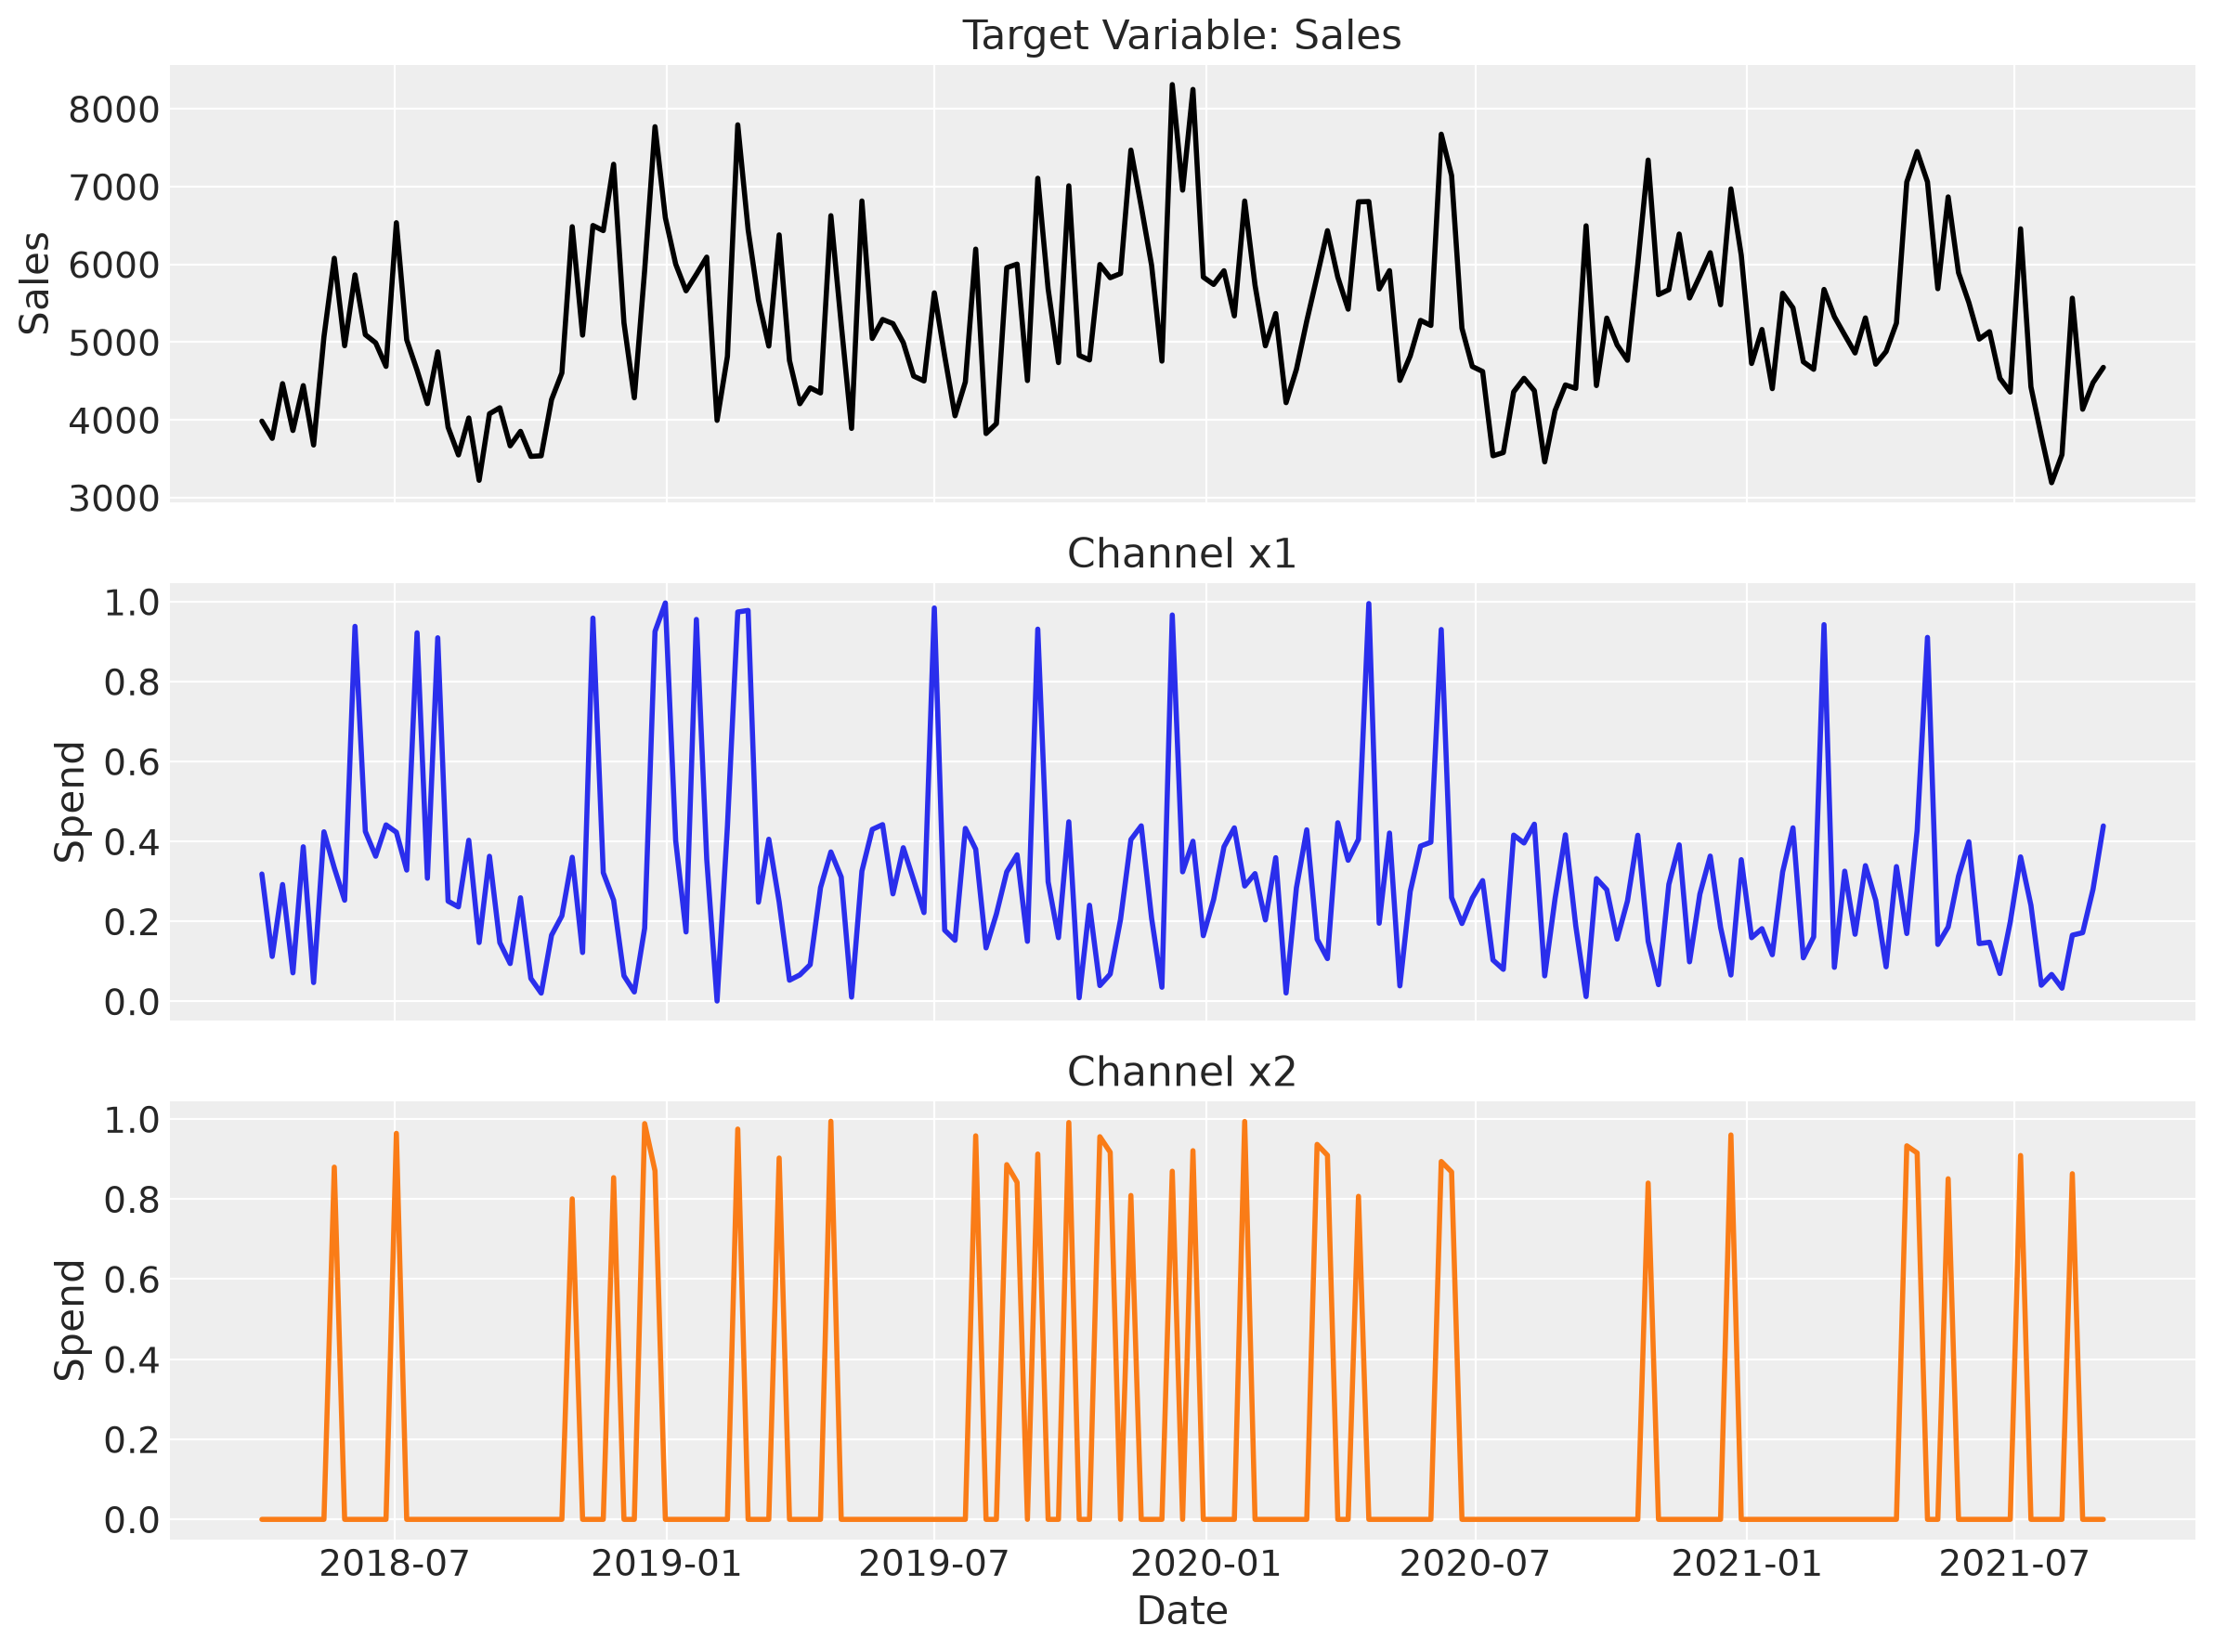

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Sales
axes[0].plot(data["date_week"], data["y"], color="black", linewidth=2)
axes[0].set(ylabel="Sales", title="Target Variable: Sales")

# Channel 1
axes[1].plot(data["date_week"], data["x1"], color="C0", linewidth=2)
axes[1].set(ylabel="Spend", title="Channel x1")

# Channel 2
axes[2].plot(data["date_week"], data["x2"], color="C1", linewidth=2)
axes[2].set(xlabel="Date", ylabel="Spend", title="Channel x2")
fig.tight_layout()

In [4]:
initial_data = data.iloc[:MIN_OBSERVATIONS]
fixed_target_scale = float(initial_data[TARGET_COLUMN].max())
fixed_channel_scales = {
    channel: float(initial_data[channel].max()) for channel in CHANNELS
}
fixed_scaling = Scaling(
    target=FixedScaling(dims=(), value=fixed_target_scale),
    channel=FixedScaling(dims=(), value=fixed_channel_scales),
)

scale_table = pd.DataFrame(
    {
        "variable": ["target", *CHANNELS],
        "fixed_scale": [fixed_target_scale, *fixed_channel_scales.values()],
        "source_rows": [f"0:{MIN_OBSERVATIONS}"] * (len(CHANNELS) + 1),
    }
)
scale_table

,variable,fixed_scale,source_rows
0,target,8312.407544,0:104
1,x1,0.996658,0:104
2,x2,0.994374,0:104


## Which MMM Specifications Are Being Compared?

The models share the same target, media channels, adstock family, seasonality order, and fixed scaling. They
differ in link function, saturation function, likelihood, priors, and trend parameterization. These
differences encode alternative assumptions about how media effects and baseline dynamics enter the sales
equation, not just alternative software settings.

- **Additive:** an identity link treats transformed channel contributions as additive changes in sales, a
  familiar baseline for budget-response interpretation.
- **Additive, tight priors:** the same business structure is deliberately constrained to test whether
  overconfident prior beliefs hurt future prediction.
- **Log / multiplicative:** a log link and LogNormal likelihood express channel effects as proportional
  changes, which is natural when positive sales variability grows with the level.
- **Log-log:** log saturation adds a different diminishing-returns shape, testing whether a more
  elasticity-like response better describes the channel-spend relationship.

The tight-prior additive model is included as a stress test: it is useful for showing that LFO-CV can
penalize an implausibly rigid model, but it is not recommended as a production prior choice.


In [5]:
total_spend = initial_data[CHANNELS].sum()
spend_share = total_spend / total_spend.sum()
prior_sigma = len(CHANNELS) * spend_share.to_numpy()

additive_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.5), dims="date"),
}

additive_tight_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.02),
    "saturation_beta": Prior("HalfNormal", sigma=0.05 * prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.005, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.01, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.5), dims="date"),
}

log_model_config = {
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
}


def make_mmm(model_name: str) -> MMM:
    common_kwargs = dict(
        target_column=TARGET_COLUMN,
        date_column=DATE_COLUMN,
        channel_columns=CHANNELS,
        yearly_seasonality=2,
        adstock=GeometricAdstock(l_max=8),
        scaling=fixed_scaling,
    )
    match model_name:
        case "additive":
            return MMM(
                model_config=additive_model_config,
                control_columns=CONTROL_COLUMNS_ADDITIVE,
                saturation=LogisticSaturation(),
                link="identity",
                **common_kwargs,
            )
        case "additive_tight":
            return MMM(
                model_config=additive_tight_model_config,
                control_columns=CONTROL_COLUMNS_ADDITIVE,
                saturation=LogisticSaturation(),
                link="identity",
                **common_kwargs,
            )
        case "log":
            return MMM(
                model_config=log_model_config,
                control_columns=CONTROL_COLUMNS_LOG,
                saturation=LogisticSaturation(),
                link="log",
                **common_kwargs,
            )
        case "loglog":
            return MMM(
                model_config=log_model_config,
                control_columns=CONTROL_COLUMNS_LOG,
                saturation=LogSaturation(),
                link="log",
                **common_kwargs,
            )
        case _:
            raise ValueError(f"Unknown model name: {model_name}")


MODEL_NAMES = ["additive", "additive_tight", "log", "loglog"]
MODEL_LABELS = {
    "additive": "Additive (identity)",
    "additive_tight": "Additive (tight priors)",
    "log": "Log (multiplicative)",
    "loglog": "Log-log",
}

## LFO wrapper for PyMC-Marketing

`arviz_stats.lfo_cv` is model-agnostic: it only needs a small interface that says how to refit a model for a
set of observations and how to score future observations under the refitted posterior.  PyMC-Marketing's
`MMM` class already knows how to build, fit, and predict, but it does not expose that exact LFO-CV interface
directly.

The wrapper below is the adapter between the two APIs.  For each requested forecast origin it:

1. selects the expanding training prefix and the future observation to score,
2. rebuilds the same MMM specification with the fixed scaling constants, 3. exposes a `sample` method that
   `lfo_cv` calls when PSIS diagnostics require an exact refit, and 4. computes the held-out log likelihood
   on the forecast week while preserving adstock history.

This is the main technical bridge in the notebook: the statistical comparison is generic LFO-CV, while the
model fitting and data transformations remain ordinary PyMC-Marketing MMM operations.

In [6]:
class PyMCMarketingLfoWrapper(SamplingWrapper):
    """Refit a PyMC-Marketing MMM on a prefix and score future observations."""

    def __init__(self, model_name: str, fit_kwargs: dict, source_data: pd.DataFrame):
        """Store the model name, fit configuration, and full pre-holdout data."""
        super().__init__(model=None, idata_orig=None)
        self.model_name = model_name
        self.fit_kwargs = dict(fit_kwargs)
        self.source_data = source_data.sort_values(DATE_COLUMN).reset_index(drop=True)
        self.n_time = len(self.source_data)
        self.current_cutoff = None
        self.current_mmm = None
        self.fit_count = 0
        self.refit_rows = []

    def sel_observations(self, idx):
        """Return the expanding training prefix and excluded future rows."""
        idx = np.atleast_1d(idx).astype(int)
        self.current_cutoff = int(idx.min())
        train = self.source_data.iloc[: self.current_cutoff].copy()
        excluded = self.source_data.iloc[idx].copy()
        return train, excluded

    def sample(self, modified_observed_data):
        """Fit the candidate MMM on the supplied training prefix."""
        self.fit_count += 1
        mmm_i = make_mmm(self.model_name)
        x_train = modified_observed_data.drop(columns=[TARGET_COLUMN])
        y_train = modified_observed_data[TARGET_COLUMN]
        idata_i = mmm_i.fit(X=x_train, y=y_train, **self.fit_kwargs)

        actual_target_scale = float(idata_i["constant_data"]["target_scale"])
        actual_channel_scale = idata_i["constant_data"]["channel_scale"]
        if not np.isclose(actual_target_scale, fixed_target_scale):
            raise ValueError(f"Unexpected target scale for {self.model_name}.")
        expected_channel_scale = (
            xr.ones_like(actual_channel_scale)
            if self.model_name == "loglog"
            else xr.DataArray(
                [fixed_channel_scales[channel] for channel in CHANNELS],
                dims=["channel"],
                coords={"channel": CHANNELS},
            )
        )
        if not np.allclose(actual_channel_scale, expected_channel_scale):
            raise ValueError(f"Unexpected channel scale for {self.model_name}.")

        self.current_mmm = mmm_i
        forecast_date = (
            self.source_data[DATE_COLUMN].iloc[self.current_cutoff]
            if self.current_cutoff is not None and self.current_cutoff < self.n_time
            else pd.NaT
        )
        self.refit_rows.append(
            {
                "model": self.model_name,
                "fit_count": self.fit_count,
                "cutoff": self.current_cutoff,
                "n_train": len(modified_observed_data),
                "fit_date": modified_observed_data[DATE_COLUMN].iloc[-1],
                "forecast_date": forecast_date,
                "target_scale": actual_target_scale,
                "channel_scale_x1": float(actual_channel_scale.sel(channel="x1")),
                "channel_scale_x2": float(actual_channel_scale.sel(channel="x2")),
            }
        )
        return mmm_i

    def get_inference_data(self, fitted_model):
        """Return the fitted model's DataTree."""
        return fitted_model.idata

    def log_likelihood__i(self, excluded_obs, idata__i):
        """Compute log likelihood for the excluded forecast rows."""
        mmm_i = self.current_mmm
        x_excluded = excluded_obs.drop(columns=[TARGET_COLUMN])
        y_excluded = excluded_obs[TARGET_COLUMN]
        dataset_xarray = mmm_i._posterior_predictive_data_transformation(
            X=x_excluded,
            y=y_excluded,
            include_last_observations=True,
        )
        model = mmm_i.model.copy()
        model = mmm_i._set_xarray_data(dataset_xarray=dataset_xarray, model=model)
        for mu_effect in mmm_i.mu_effects:
            mu_effect.set_data(mmm_i, model, dataset_xarray)

        idata_for_ll = idata__i.copy()
        if "log_likelihood" in idata_for_ll:
            del idata_for_ll["log_likelihood"]
        pm.compute_log_likelihood(
            idata_for_ll,
            var_names=[mmm_i.output_var],
            model=model,
            progressbar=False,
        )
        log_lik = idata_for_ll["log_likelihood"][mmm_i.output_var]
        log_lik = log_lik.isel(date=slice(-len(excluded_obs), None))
        log_lik = log_lik.assign_coords(
            date=np.asarray(excluded_obs[DATE_COLUMN].values)
        )
        return log_lik

## Run approximate LFO-CV

We now fit all candidate models and evaluate the one-week-ahead sliding forecast window.

The first fit for each model is restricted to the pre-holdout data. LFO-CV then scores every eligible
pre-holdout origin, using PSIS where possible and exact refits when `pareto_k > K_THRESHOLD`. The pointwise
ELPD values are the log predictive scores for each forecast origin.

We use a conservative threshold, $\hat{k}=0.5$. This keeps accepted PSIS updates in the better-behaved
finite-variance regime for the raw importance ratios. The more common $\hat{k}=0.7$ threshold is often
sufficient, especially during exploratory model development, and would usually reduce the number of exact
refits further. Pareto-$k$ is still a diagnostic rather than a deterministic error bound.


In [7]:
fit_kwargs = {
    "chains": 4,
    "target_accept": 0.9,
    "draws": 2000,
    "tune": 1000,
    "nuts_sampler": "nutpie",
    "random_seed": SEED,
    "progressbar": False,
    "quiet": True,
}


def fit_reference_model(model_name: str, fit_data: pd.DataFrame):
    mmm = make_mmm(model_name)
    x_fit = fit_data.drop(columns=[TARGET_COLUMN])
    y_fit = fit_data[TARGET_COLUMN]
    idata = mmm.fit(X=x_fit, y=y_fit, **fit_kwargs)
    pm.compute_log_likelihood(
        idata,
        var_names=[mmm.output_var],
        model=mmm.model,
        progressbar=False,
    )
    return mmm, idata


def run_one_lfo(model_name: str, fit_data: pd.DataFrame, method: str = "approx"):
    reference_mmm, reference_idata = fit_reference_model(model_name, fit_data)
    wrapper = PyMCMarketingLfoWrapper(
        model_name,
        fit_kwargs=fit_kwargs,
        source_data=fit_data,
    )
    result = lfo_cv(
        reference_idata,
        wrapper=wrapper,
        min_observations=MIN_OBSERVATIONS,
        forecast_horizon=FORECAST_HORIZON,
        time_dim="date",
        var_name=reference_mmm.output_var,
        method=method,
        k_threshold=K_THRESHOLD,
        pointwise=True,
    )
    return result, wrapper, reference_mmm


lfo_cutoff = len(data) - HOLDOUT_WEEKS
if lfo_cutoff <= MIN_OBSERVATIONS:
    raise ValueError("The holdout leaves too few observations for LFO-CV")
lfo_data = data.iloc[:lfo_cutoff].copy()

lfo_runs = {}
for model_name in MODEL_NAMES:
    lfo_runs[model_name] = run_one_lfo(model_name, lfo_data)

lfo_results = {name: run[0] for name, run in lfo_runs.items()}
lfo_wrappers = {name: run[1] for name, run in lfo_runs.items()}
reference_mmm_by_model = {name: run[2] for name, run in lfo_runs.items()}

Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

In [8]:
lfo_summary = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[name],
            "ELPD_LFO": result.elpd,
            "SE": result.se,
            "origins": result.n_data_points,
            "PSIS_refits": result.n_refits,
        }
        for name, result in lfo_results.items()
    ]
).sort_values("ELPD_LFO", ascending=False)
lfo_summary

,model,ELPD_LFO,SE,origins,PSIS_refits
2,Log (multiplicative),94.521022,5.243395,49,2
3,Log-log,85.713241,5.733069,49,2
0,Additive (identity),83.746738,17.617025,49,2
1,Additive (tight priors),65.767919,21.416995,49,2


## How Are Pointwise and Aggregate ELPD Compared?

First, we use the LFO-CV results for ordinary model comparison: which single model has the best expected
one-week-ahead predictive performance? **Pointwise ELPD** is the log predictive density contributed by one
held-out forecast origin. **Aggregate ELPD** is the sum of those pointwise contributions across the common
evaluation origins, and is the quantity used to rank the candidate models here. Higher aggregate ELPD means
that the model assigned better predictive density to the observed future values for this evaluation task.

A useful ELPD difference is therefore a comparative statement about expected predictive accuracy on these
origins, not a universal pass/fail threshold. Read it with the paired standard error and the same-origin
uncertainty: a small difference relative to its uncertainty need not support a confident single-model
choice. ELPD also evaluates prediction, not causal identification or ROAS.

```{note}
**What is ELPD?** Expected log predictive density is the average log probability that a model assigns to future
observations. In this notebook each pointwise contribution is the log predictive density for one held-out forecast
week. Higher values mean the model placed more probability mass near what actually happened.

See the [Stan loo guide to leave-future-out cross-validation][stan-loo] for the relationship between pointwise scores,
aggregate comparisons, and uncertainty in LFO workflows.
```


In [9]:
lfo_comparison = compare(lfo_results, method="stacking", round_to="none")
ranking_columns = [
    "rank",
    "elpd",
    "se",
    "elpd_diff",
    "dse",
    "p_worse",
    "diag_elpd",
    "weight",
]
lfo_comparison.sort_values(by="rank")[ranking_columns].round(3)

,rank,elpd,se,elpd_diff,dse,p_worse,diag_elpd,weight
log,0,94.521,5.243,0.000,0.000,NaN,,0.377
loglog,1,85.713,5.733,-8.808,2.770,0.999,,0.000
additive,2,83.747,17.617,-10.774,14.900,0.765,,0.623
additive_tight,3,65.768,21.417,-28.753,19.119,0.934,,0.000


## Stacking predictive distributions

Model ranking answers one question: *which single model would we choose if we had to pick exactly one?*
Stacking answers a different question: *can a weighted mixture of the candidate predictive distributions
forecast better than any single model?*

This is useful in MMM because alternative structural assumptions can capture different aspects of the data.
For example, an additive model and a log-link model may make different errors at different forecast origins.
Stacking uses the pre-holdout LFO scores to estimate weights for a predictive mixture, allowing the ensemble
to keep complementary information from multiple plausible models instead of making an all-or-nothing
selection.

An important feature of stacking is that the model with the largest stacking weight does not have to be the
model with the best ELPD rank. This is not a contradiction. Stacking rewards models that add complementary
predictive information to the ensemble. A model can rank lower on its own but still improve the mixture
because it makes different errors than the top-ranked model. Similarly, a high-ranked model can receive
little weight if its predictions are mostly redundant with a better model.

In [10]:
stacking_columns = ["rank", "elpd", "se", "elpd_diff", "dse", "weight"]
lfo_comparison.sort_values(by="weight", ascending=False)[stacking_columns].round(3)

,rank,elpd,se,elpd_diff,dse,weight
additive,2,83.747,17.617,-10.774,14.900,0.623
log,0,94.521,5.243,0.000,0.000,0.377
loglog,1,85.713,5.733,-8.808,2.770,0.000
additive_tight,3,65.768,21.417,-28.753,19.119,0.000


## Exact LFO-CV reference

Approximate LFO-CV saves time by replacing many full refits with PSIS updates. The case study ships a
compact, inspectable JSON artifact containing exact pointwise results and the metadata needed to reconstruct
exact aggregate comparisons. The notebook loads it only when its deterministic fingerprint matches the
normalized data, model/settings, wrapper implementation, and package/API assumptions used here.

If the artifact is missing, malformed, or stale, the notebook reports that it is not trusted and recomputes
each model through the same `run_one_lfo(..., method="exact")` wrapper used by approximate LFO-CV. External
precomputation can create a replacement artifact, but it must use the same fingerprint inputs. Set
`MMM_LFO_CV_WRITE_ARTIFACT=1` during an intentional precomputation to serialize validated exact results;
ordinary notebook execution never writes cache files.

The table below compares approximate and exact **pointwise** ELPD values before summarizing their aggregate
differences. The difference is on the log predictive density scale: a pointwise error of 0.01 means that the
PSIS approximation and exact refit assign predictive densities to the observed sales that differ by about 1%
at that forecast origin. This retrospective exact-reference comparison is a validation aid; it does not
change the configured automatic refit rule.

**Figure description.** The exact-reference panels compare approximate and exact pointwise ELPD across
forecast origins for each candidate. Similar traces indicate close predictive agreement; visible deviations
identify origins worth examining with the diagnostic and refit information below.


In [11]:
EXACT_ARTIFACT_SCHEMA = "mmm-lfo-cv-exact-v2"
EXACT_WRAPPER_VERSION = "pymc-marketing-mmm-lfo-wrapper-v2"
EXACT_ARTIFACT_CANDIDATES = (
    Path("data/mmm_lfo_cv_exact_results.json"),
    Path("../../../../data/mmm_lfo_cv_exact_results.json"),
)


def _canonical_json(value):
    return json.dumps(value, sort_keys=True, separators=(",", ":"), allow_nan=False)


def _json_safe(value):
    """Convert model-specification values to deterministic JSON-compatible data."""
    if isinstance(value, Prior):
        return _json_safe(value.to_dict())
    if isinstance(value, xr.DataArray):
        return {
            "dims": list(value.dims),
            "coords": _json_safe(
                {
                    name: np.asarray(coord.values).tolist()
                    for name, coord in value.coords.items()
                }
            ),
            "values": _json_safe(value.values),
        }
    if isinstance(value, np.ndarray):
        return _json_safe(value.tolist())
    if isinstance(value, np.generic):
        return _json_safe(value.item())
    if isinstance(value, dict):
        return {str(key): _json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


def _prior_mapping(priors):
    return {name: _json_safe(prior) for name, prior in priors.items()}


def _scaling_spec(scaling):
    return {
        "class": type(scaling).__name__,
        "dims": list(scaling.dims),
        "method": scaling.method,
        "value": _json_safe(getattr(scaling, "value", None)),
    }


def _model_specification(model_name: str):
    """Return the complete effective MMM specification, including nested priors."""
    mmm = make_mmm(model_name)
    return {
        "constructor": {
            "date_column": mmm.date_column,
            "target_column": mmm.target_column,
            "channel_columns": list(mmm.channel_columns),
            "control_columns": list(mmm.control_columns or []),
            "dims": list(mmm.dims),
            "link": mmm.link.value,
            "yearly_seasonality": mmm.yearly_seasonality,
            "adstock_first": mmm.adstock_first,
            "time_varying_intercept": bool(mmm.time_varying_intercept),
            "time_varying_media": bool(mmm.time_varying_media),
        },
        "adstock": {
            "class": type(mmm.adstock).__name__,
            "l_max": mmm.adstock.l_max,
            "normalize": mmm.adstock.normalize,
            "mode": str(mmm.adstock.mode),
            "priors": _prior_mapping(mmm.adstock._function_priors),
        },
        "saturation": {
            "class": type(mmm.saturation).__name__,
            "priors": _prior_mapping(mmm.saturation._function_priors),
        },
        "scaling": {
            "target": _scaling_spec(mmm.scaling.target),
            "channel": _scaling_spec(mmm.scaling.channel),
        },
        "model_config": _json_safe(mmm.model_config),
    }


def _package_versions():
    packages = (
        "arviz-base",
        "arviz-stats",
        "pymc",
        "pymc-extras",
        "pymc-marketing",
        "pytensor",
        "xarray",
    )
    return {package: importlib.metadata.version(package) for package in packages}


def exact_lfo_fingerprint_inputs(fit_data: pd.DataFrame):
    data_columns = [
        DATE_COLUMN,
        TARGET_COLUMN,
        *CHANNELS,
        "event_1",
        "event_2",
        "t",
        "t_norm",
    ]
    normalized = fit_data[data_columns].copy()
    normalized[DATE_COLUMN] = pd.to_datetime(normalized[DATE_COLUMN]).dt.strftime(
        "%Y-%m-%dT%H:%M:%S.%fZ"
    )
    data_digest = hashlib.sha256(
        _canonical_json(normalized.to_dict(orient="records")).encode()
    ).hexdigest()
    settings = {
        "seed": SEED,
        "min_observations": MIN_OBSERVATIONS,
        "holdout_weeks": HOLDOUT_WEEKS,
        "forecast_horizon": FORECAST_HORIZON,
        "k_threshold": K_THRESHOLD,
        "fit_kwargs": fit_kwargs,
        "models": MODEL_NAMES,
        "model_labels": MODEL_LABELS,
        "channels": CHANNELS,
        "control_columns_additive": CONTROL_COLUMNS_ADDITIVE,
        "control_columns_log": CONTROL_COLUMNS_LOG,
        "date_column": DATE_COLUMN,
        "target_column": TARGET_COLUMN,
        "fixed_target_scale": fixed_target_scale,
        "fixed_channel_scales": fixed_channel_scales,
        "model_specifications": {
            name: _model_specification(name) for name in MODEL_NAMES
        },
    }
    return {
        "schema": EXACT_ARTIFACT_SCHEMA,
        "data_sha256": data_digest,
        "settings": settings,
        "wrapper_version": EXACT_WRAPPER_VERSION,
        "computation": {
            "method": "exact",
            "api": "arviz_stats.lfo_cv",
            "pointwise": True,
            "time_dim": "date",
            "var_name": "y",
        },
        "package_versions": _package_versions(),
    }


def exact_lfo_fingerprint(fit_data: pd.DataFrame):
    inputs = exact_lfo_fingerprint_inputs(fit_data)
    return hashlib.sha256(_canonical_json(inputs).encode()).hexdigest(), inputs


def _artifact_path():
    return next(
        (path for path in EXACT_ARTIFACT_CANDIDATES if path.is_file()),
        EXACT_ARTIFACT_CANDIDATES[0],
    )


def _serialized_result_payload(exact_results):
    payload = {}
    for name in MODEL_NAMES:
        result = exact_results[name]
        payload[name] = {
            "date": [
                timestamp.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
                for timestamp in pd.to_datetime(result.elpd_i.coords["date"].values)
            ],
            "exact_elpd_i": [float(value) for value in result.elpd_i.values],
            "exact_p_lfo_i": [float(value) for value in result.p_lfo_i.values],
            "elpd": float(result.elpd),
            "se": float(result.se),
            "p": float(result.p),
            "n_samples": int(result.n_samples),
            "n_data_points": int(result.n_data_points),
            "n_refits": int(result.n_refits),
            "refits": [int(value) for value in result.refits],
            "forecast_horizon": int(result.forecast_horizon),
            "min_observations": int(result.min_observations),
        }
    return payload


def _result_from_artifact(name, record):
    dates = pd.to_datetime(record["date"], utc=True).tz_localize(None).to_numpy()
    exact_elpd_i = xr.DataArray(
        np.asarray(record["exact_elpd_i"], dtype=float),
        dims=["date"],
        coords={"date": dates},
    )
    exact_p_lfo_i = xr.DataArray(
        np.asarray(record["exact_p_lfo_i"], dtype=float),
        dims=["date"],
        coords={"date": dates},
    )
    return ELPDData(
        kind="lfo_cv",
        elpd=float(record["elpd"]),
        se=float(record["se"]),
        p=float(record["p"]),
        n_samples=int(record["n_samples"]),
        n_data_points=int(record["n_data_points"]),
        scale="log",
        warning=False,
        good_k=None,
        elpd_i=exact_elpd_i,
        pareto_k=None,
        forecast_horizon=int(record["forecast_horizon"]),
        min_observations=int(record["min_observations"]),
        refits=np.asarray(record["refits"], dtype=int),
        n_refits=int(record["n_refits"]),
        p_lfo_i=exact_p_lfo_i,
    )


def _strict_json_integer(value, field_name):
    """Validate JSON integer metadata without accepting bools or coercions."""
    if isinstance(value, bool) or not isinstance(value, int):
        raise ValueError(f"{field_name} must be a JSON integer")
    return value


def _strict_json_integer_list(value, field_name):
    if not isinstance(value, list):
        raise ValueError(f"{field_name} must be a list of JSON integers")
    for index, item in enumerate(value):
        _strict_json_integer(item, f"{field_name}[{index}]")
    return value


def _validate_result_record(name, record, expected_dates):
    required = {
        "date",
        "exact_elpd_i",
        "exact_p_lfo_i",
        "elpd",
        "se",
        "p",
        "n_samples",
        "n_data_points",
        "n_refits",
        "refits",
        "forecast_horizon",
        "min_observations",
    }
    if set(record) != required:
        raise ValueError(f"unexpected result fields for {name}")
    # Validate all integer metadata before any int() or NumPy conversion. JSON
    # booleans are Python ints, so they need an explicit rejection here.
    n_samples = _strict_json_integer(record["n_samples"], "n_samples")
    n_data_points = _strict_json_integer(record["n_data_points"], "n_data_points")
    n_refits = _strict_json_integer(record["n_refits"], "n_refits")
    forecast_horizon = _strict_json_integer(
        record["forecast_horizon"], "forecast_horizon"
    )
    min_observations = _strict_json_integer(
        record["min_observations"], "min_observations"
    )
    raw_refits = _strict_json_integer_list(record["refits"], "refits")
    dates = pd.to_datetime(record["date"], utc=True).tz_localize(None).to_numpy()
    elpd_i = np.asarray(record["exact_elpd_i"], dtype=float)
    p_lfo_i = np.asarray(record["exact_p_lfo_i"], dtype=float)
    if (
        elpd_i.ndim != 1
        or p_lfo_i.ndim != 1
        or len(dates) != len(elpd_i)
        or len(elpd_i) != len(p_lfo_i)
        or not np.isfinite(elpd_i).all()
        or not np.isfinite(p_lfo_i).all()
    ):
        raise ValueError(f"invalid pointwise values for {name}")
    if not np.array_equal(dates, expected_dates):
        raise ValueError(f"date coordinates do not match for {name}")
    if n_data_points != len(elpd_i) or n_data_points <= 0:
        raise ValueError(f"n_data_points does not match pointwise values for {name}")
    if forecast_horizon != FORECAST_HORIZON:
        raise ValueError(f"forecast_horizon mismatch for {name}")
    if min_observations != MIN_OBSERVATIONS:
        raise ValueError(f"min_observations mismatch for {name}")
    refits = np.asarray(raw_refits, dtype=int)
    expected_refits = np.arange(min_observations, min_observations + n_data_points)
    if n_refits != len(refits) or not np.array_equal(refits, expected_refits):
        raise ValueError(f"refit metadata does not match n_data_points for {name}")
    expected_n_samples = int(fit_kwargs["chains"]) * int(fit_kwargs["draws"])
    if n_samples != expected_n_samples:
        raise ValueError(f"n_samples mismatch for {name}")
    expected_elpd = float(elpd_i.sum())
    expected_p = float(p_lfo_i.sum())
    expected_se = float(np.sqrt(len(elpd_i)) * np.std(elpd_i))
    if not np.isclose(float(record["elpd"]), expected_elpd, rtol=1e-10, atol=1e-12):
        raise ValueError(f"elpd aggregate mismatch for {name}")
    if not np.isclose(float(record["p"]), expected_p, rtol=1e-10, atol=1e-12):
        raise ValueError(f"p aggregate mismatch for {name}")
    if not np.isclose(float(record["se"]), expected_se, rtol=1e-10, atol=1e-12):
        raise ValueError(f"se aggregate mismatch for {name}")


def load_exact_lfo_artifact(fit_data: pd.DataFrame):
    fingerprint, inputs = exact_lfo_fingerprint(fit_data)
    path = _artifact_path()
    if not path.is_file():
        print(f"No shipped exact LFO artifact at {path}; recomputing exact results.")
        return None
    try:
        with path.open(encoding="utf-8") as file:
            artifact = json.load(file)
        if artifact["schema"] != EXACT_ARTIFACT_SCHEMA:
            raise ValueError("unsupported artifact schema")
        if artifact["fingerprint"] != fingerprint:
            raise ValueError("fingerprint mismatch")
        if artifact["fingerprint_inputs"] != inputs:
            raise ValueError("fingerprint inputs mismatch")
        records = artifact["results"]
        if set(records) != set(MODEL_NAMES):
            raise ValueError("result model names mismatch")
        expected_payload_hash = hashlib.sha256(
            _canonical_json(records).encode()
        ).hexdigest()
        if artifact["result_payload_sha256"] != expected_payload_hash:
            raise ValueError("result payload hash mismatch")
        expected_dates = {
            name: (
                pd.to_datetime(lfo_results[name].elpd_i.coords["date"].values, utc=True)
                .tz_localize(None)
                .to_numpy()
            )
            for name in MODEL_NAMES
        }
        exact_results = {}
        for name in MODEL_NAMES:
            _validate_result_record(name, records[name], expected_dates[name])
            exact_results[name] = _result_from_artifact(name, records[name])
    except (
        OSError,
        OverflowError,
        KeyError,
        TypeError,
        ValueError,
        json.JSONDecodeError,
    ) as error:
        print(
            f"Ignoring invalid shipped exact LFO artifact ({error}); recomputing exact results."
        )
        return None
    print(f"Loaded shipped exact LFO artifact from {path}.")
    return exact_results


def _run_malformed_artifact_probes():
    """Exercise strict metadata rejection without starting any model refits."""
    path = _artifact_path()
    if not path.is_file():
        raise AssertionError(f"probe artifact is missing: {path}")
    artifact = json.loads(path.read_text(encoding="utf-8"))
    model_name = MODEL_NAMES[0]
    expected_dates = (
        pd.to_datetime(lfo_results[model_name].elpd_i.coords["date"].values, utc=True)
        .tz_localize(None)
        .to_numpy()
    )
    valid_record = artifact["results"][model_name]
    invalid_metadata = {
        "n_samples": True,
        "n_data_points": 1.5,
        "n_refits": "4",
        "forecast_horizon": None,
        "min_observations": False,
        "refits": [*valid_record["refits"][:-1], 104.0],
    }
    for field, invalid_value in invalid_metadata.items():
        record = json.loads(json.dumps(valid_record))
        record[field] = invalid_value
        try:
            _validate_result_record(model_name, record, expected_dates)
        except ValueError:
            pass
        else:
            raise AssertionError(f"malformed metadata was accepted: {field}")
    oversized_refits = json.loads(json.dumps(valid_record))
    oversized_refits["refits"][0] = 2**100
    try:
        _validate_result_record(model_name, oversized_refits, expected_dates)
    except OverflowError:
        pass
    else:
        raise AssertionError("oversized refit metadata did not raise OverflowError")


def save_exact_lfo_artifact(fit_data: pd.DataFrame, exact_results):
    fingerprint, inputs = exact_lfo_fingerprint(fit_data)
    results = _serialized_result_payload(exact_results)
    artifact = {
        "schema": EXACT_ARTIFACT_SCHEMA,
        "fingerprint": fingerprint,
        "fingerprint_inputs": inputs,
        "result_payload_sha256": hashlib.sha256(
            _canonical_json(results).encode()
        ).hexdigest(),
        "results": results,
    }
    path = EXACT_ARTIFACT_CANDIDATES[0]
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(_canonical_json(artifact) + "\n", encoding="utf-8")
    print(f"Wrote validated exact LFO artifact to {path}.")


exact_lfo_results = load_exact_lfo_artifact(lfo_data)
if exact_lfo_results is not None:
    _run_malformed_artifact_probes()
if exact_lfo_results is None:
    exact_lfo_runs = {
        name: run_one_lfo(name, lfo_data, method="exact") for name in MODEL_NAMES
    }
    exact_lfo_results = {name: run[0] for name, run in exact_lfo_runs.items()}
    if os.environ.get("MMM_LFO_CV_WRITE_ARTIFACT") == "1":
        save_exact_lfo_artifact(lfo_data, exact_lfo_results)

exact_elpd_i_by_model = {
    name: result.elpd_i for name, result in exact_lfo_results.items()
}

exact_lfo_comparison = compare(exact_lfo_results, method="stacking", round_to="none")
exact_weights_by_name = exact_lfo_comparison["weight"].to_dict()

approximation_rows = []
for name in MODEL_NAMES:
    approx = lfo_results[name]
    exact = exact_lfo_results[name]
    pointwise_error = approx.elpd_i - exact.elpd_i
    max_abs_error = float(np.abs(pointwise_error).max())
    approximation_rows.append(
        {
            "model": MODEL_LABELS[name],
            "PSIS_ELPD": approx.elpd,
            "exact_ELPD": exact.elpd,
            "PSIS_minus_exact": approx.elpd - exact.elpd,
            "max_abs_pointwise_error": max_abs_error,
            "exact_refits_saved": exact.n_refits - approx.n_refits,
            "PSIS_weight": lfo_comparison.loc[name, "weight"],
            "exact_weight": exact_weights_by_name[name],
        }
    )

approximation_summary = pd.DataFrame(approximation_rows).sort_values(
    "PSIS_ELPD", ascending=False
)
approximation_summary.round(3)

Loaded shipped exact LFO artifact from ../../../../data/mmm_lfo_cv_exact_results.json.


,model,PSIS_ELPD,exact_ELPD,PSIS_minus_exact,max_abs_pointwise_error,exact_refits_saved,PSIS_weight,exact_weight
2,Log (multiplicative),94.521,94.146,0.375,0.101,47,0.377,0.366
3,Log-log,85.713,85.702,0.011,0.040,47,0.000,0.000
0,Additive (identity),83.747,86.723,-2.977,3.057,47,0.623,0.634
1,Additive (tight priors),65.768,65.513,0.254,0.386,47,0.000,0.000


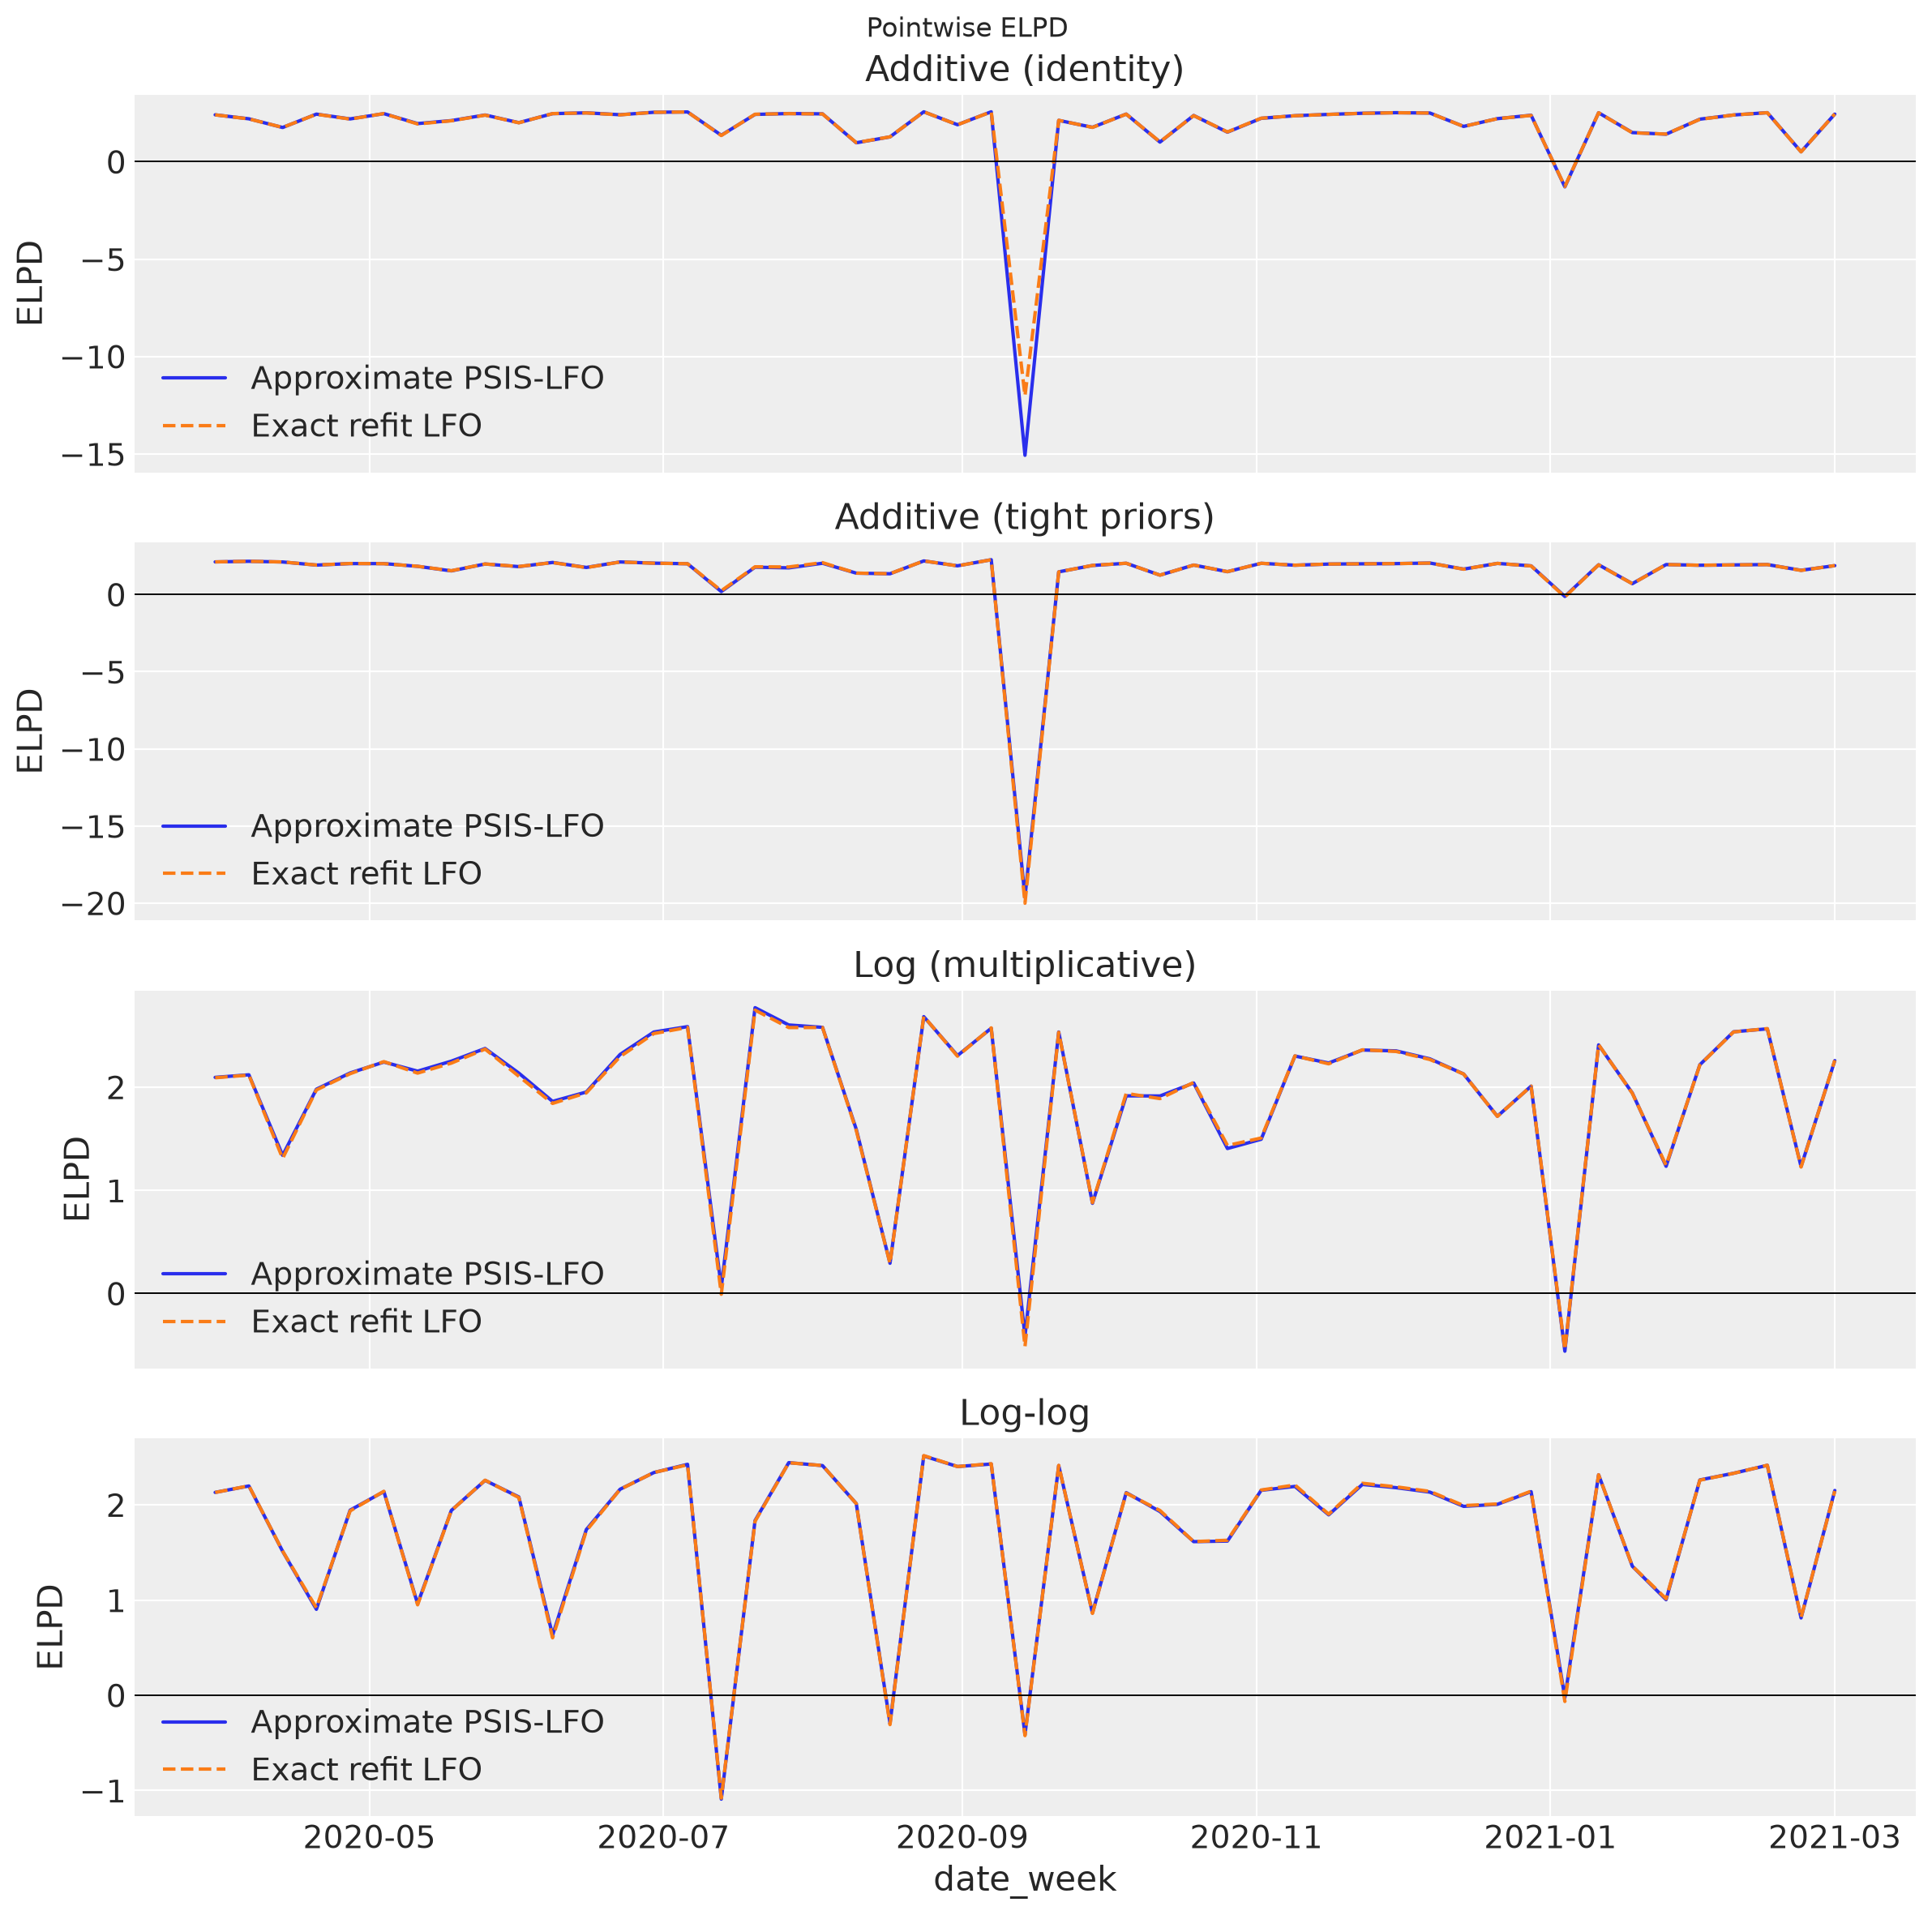

In [12]:
if exact_lfo_results:
    fig, axes = plt.subplots(
        len(MODEL_NAMES), 1, figsize=(12, 3 * len(MODEL_NAMES)), sharex=True
    )
    axes = np.atleast_1d(axes)
    for axis, model_name in zip(axes, MODEL_NAMES, strict=True):
        approx = lfo_results[model_name]
        exact = exact_lfo_results[model_name]
        dates = approx.elpd_i.coords["date"].values
        axis.plot(
            dates,
            approx.elpd_i.values,
            color="C0",
            label="Approximate PSIS-LFO",
        )
        axis.plot(
            dates,
            exact.elpd_i.values,
            color="C1",
            linestyle="--",
            label="Exact refit LFO",
        )
        axis.axhline(0, color="black", linewidth=0.7)
        axis.set_ylabel("ELPD")
        axis.set_title(MODEL_LABELS[model_name])
        axis.legend()
    axes[-1].set_xlabel(DATE_COLUMN)
    fig.suptitle("Pointwise ELPD")
    fig.tight_layout()

In [13]:
exact_lfo_comparison = compare(exact_lfo_results, method="stacking", round_to="none")
ranking_columns = [
    "rank",
    "elpd",
    "se",
    "elpd_diff",
    "dse",
    "p_worse",
    "diag_elpd",
    "weight",
]
exact_lfo_comparison.sort_values(by="rank")[ranking_columns].round(3)

,rank,elpd,se,elpd_diff,dse,p_worse,diag_elpd,weight
log,0,94.146,5.291,0.000,0.000,NaN,,0.366
additive,1,86.723,14.720,-7.423,11.859,0.734,,0.634
loglog,2,85.702,5.756,-8.444,2.728,0.999,,0.000
additive_tight,3,65.513,21.797,-28.633,19.399,0.930,,0.000


## When Should You Trust the PSIS Approximation?

Approximate LFO-CV is efficient because it reuses posterior draws with PSIS weights until the approximation
becomes unreliable. **Pareto-$k$** is a tail-shape diagnostic fitted to the importance ratios: larger values
indicate heavier tails and less reliable reweighting. The configured automatic trigger in this notebook is
`K_THRESHOLD = 0.5`; when the relevant diagnostic exceeds that value, LFO-CV performs an exact refit rather
than trusting the update. This setting is a workflow rule, not a universal error guarantee.

Trust an accepted PSIS update when the Pareto-$k$ diagnostic is within the configured regime and the
empirical approximation error is small relative to the predictive-score scale and uncertainty relevant to
the decision. The empirical approximation error shown here is the pointwise PSIS ELPD minus the pointwise
exact-refit ELPD. Values near zero mean that the approximate and exact refit assign nearly the same
predictive density to the observed sales for that forecast week; a large absolute value is evidence to
investigate, not a standalone selection threshold.

The plot below shows Pareto-$k$ on the left axis and empirical approximation error on the right axis. The
largest absolute approximation error is intentionally retained and marked as an **influential outlier**. It
is a learning point, not a nuisance to hide: a single forecast origin can expose where the PSIS
approximation differs materially from an exact refit. Read it alongside Pareto-$k$ and the refit markers.

The first vertical marker is the initial fit; subsequent vertical markers are exact refits triggered by the
automatic PSIS diagnostic. Clusters of refits or high-$k$ origins indicate forecast periods where the
posterior changes quickly. In this run, the additive model shows this pattern, which helps explain its
larger paired ELPD uncertainty.

**Figure description.** Each model panel aligns the tail diagnostic, the approximate-minus-exact pointwise
ELPD error, and vertical refit markers on the forecast-origin axis. Agreement near zero with acceptable tail
diagnostics supports using the approximation for that origin; material error or a triggered refit points to
exact computation. The retrospective exact-reference series is plotted for comparison at all origins and
should not be confused with the automatic trigger.


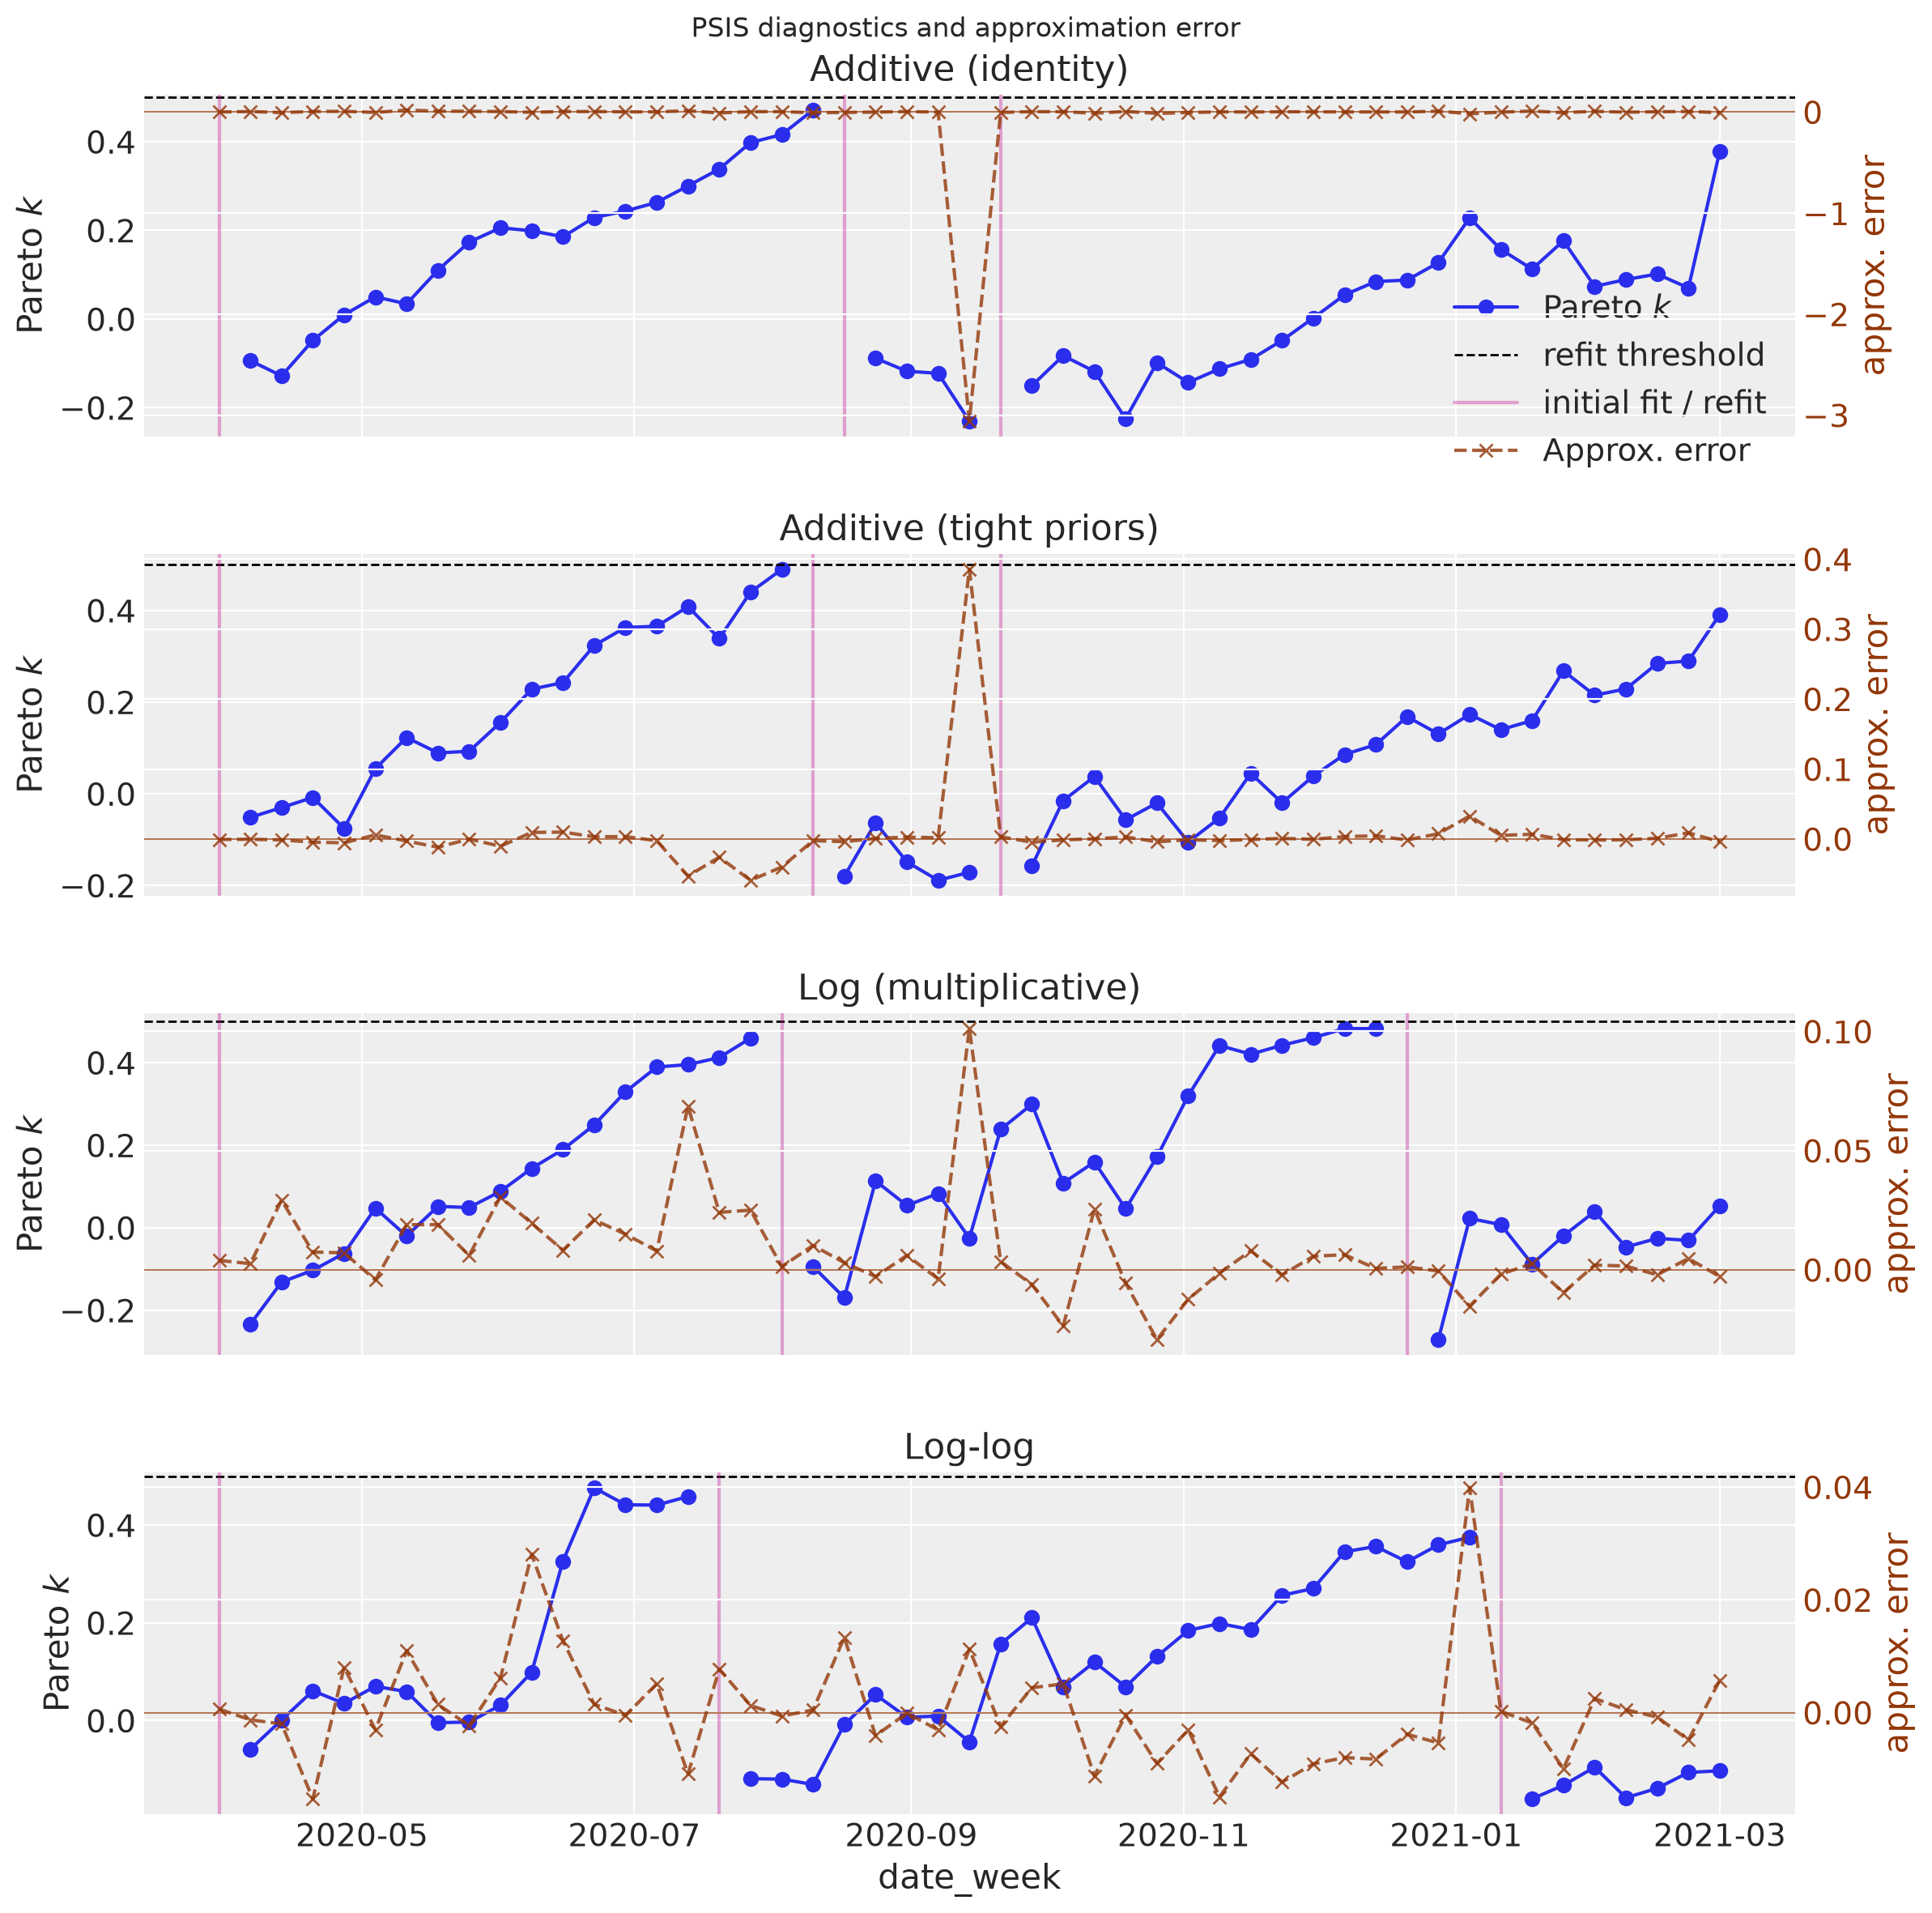

In [45]:
approximation_error_by_model = {
    model_name: lfo_results[model_name].elpd_i - exact_elpd_i_by_model[model_name]
    for model_name in MODEL_NAMES
}

fig, axes = plt.subplots(
    len(MODEL_NAMES), 1, figsize=(12, 3 * len(MODEL_NAMES)), sharex=True
)
axes = np.atleast_1d(axes)
initial_fit_date = lfo_data[DATE_COLUMN].iloc[MIN_OBSERVATIONS]
for axis, model_name in zip(axes, MODEL_NAMES, strict=True):
    result = lfo_results[model_name]
    dates = result.elpd_i.coords["date"].values

    if result.pareto_k is not None:
        axis.plot(dates, result.pareto_k.values, marker="o", label="Pareto $k$")
    axis.axhline(
        K_THRESHOLD, color="black", linestyle="--", linewidth=1, label="refit threshold"
    )
    axis.axvline(
        initial_fit_date,
        color="C3",
        alpha=0.35,
        linewidth=1.5,
        label="initial fit / refit",
    )
    for refit_idx in result.refits:
        axis.axvline(
            lfo_data[DATE_COLUMN].iloc[int(refit_idx)],
            color="C3",
            alpha=0.35,
            linewidth=1.5,
        )

    error_axis = axis.twinx()
    approximation_error = approximation_error_by_model[model_name]
    error_axis.plot(
        dates,
        approximation_error.values,
        color="C4",
        marker="x",
        linestyle="--",
        alpha=0.8,
        label="Approx. error",
    )
    error_axis.axhline(0, color="C4", linewidth=0.7, alpha=0.7)
    error_axis.set_ylabel("approx. error", color="C4")
    error_axis.tick_params(axis="y", labelcolor="C4")

    axis.set_ylabel("Pareto $k$")
    axis.set_title(MODEL_LABELS[model_name])
axes[-1].set_xlabel(DATE_COLUMN)
# Collect legend entries from the primary and secondary axes.
handles, labels = [], []
for figure_axis in fig.axes:
    axis_handles, axis_labels = figure_axis.get_legend_handles_labels()
    for handle, label in zip(axis_handles, axis_labels, strict=True):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
axes[0].legend(handles, labels, loc='best', bbox_to_anchor=(0.5, 0., 0.5, 0.5))
fig.suptitle("PSIS diagnostics and approximation error")
fig.tight_layout()

## Holdout check with pre-holdout stacking weights

The LFO-CV comparison above uses only the pre-holdout history and a one-week forecast horizon. The holdout
serves a different purpose: we reserve the last `HOLDOUT_WEEKS` observations as a **longer 26-week period
after the LFO-CV run**, estimate stacking weights from the pre-holdout LFO scores, and evaluate both the
individual models and the stacked predictive mixture on that untouched future period. It is not another
one-week LFO origin and it does not change the evaluation design.

The holdout scores are computed on the same scaled target used internally by the likelihood, so they are on
the same scale as the LFO log scores. Agreement between holdout and LFO results increases confidence that
the predictive ordering is not specific to the shorter rolling task; disagreement is useful evidence that
performance may depend on horizon or on this later regime, not proof that either evaluation is wrong.
Because the holdout has only 26 weeks, we read it together with the paired LFO standard errors rather than
treating it as a definitive re-ranking.

**Figure description.** The holdout figure tracks each model's weekly log score and CRPS over the reserved
longer period. Comparing these trajectories and the aggregate summaries with the pre-holdout LFO results
shows whether the same predictive pattern persists after the cross-validation run.


In [15]:
def holdout_predictions(mmm, holdout_data: pd.DataFrame) -> xr.DataTree:
    """Sample posterior predictions for the holdout on the model's scaled target."""
    x_holdout = holdout_data.drop(columns=[TARGET_COLUMN])
    posterior_predictive = mmm.sample_posterior_predictive(
        X=x_holdout,
        extend_idata=False,
        combined=False,
        include_last_observations=True,
        random_seed=SEED,
        progressbar=False,
    )
    samples = posterior_predictive[mmm.output_var]
    if samples.sizes["date"] != len(holdout_data):
        raise ValueError("Unexpected posterior predictive holdout length.")
    observed_scaled = holdout_data[TARGET_COLUMN].to_numpy() / float(
        mmm.scalers["_target"].item()
    )
    return xr.DataTree.from_dict(
        {
            "/posterior_predictive": xr.DataTree(
                samples.to_dataset(name=TARGET_COLUMN)
            ),
            "/observed_data": xr.DataTree(
                xr.Dataset(
                    {TARGET_COLUMN: ("date", observed_scaled)},
                    coords={"date": holdout_data[DATE_COLUMN].to_numpy()},
                )
            ),
        }
    )


def holdout_log_likelihood(mmm, idata, holdout_data: pd.DataFrame):
    """Compute exact pointwise holdout log likelihood on the scaled target."""
    x_holdout = holdout_data.drop(columns=[TARGET_COLUMN])
    y_holdout = holdout_data[TARGET_COLUMN]
    dataset_xarray = mmm._posterior_predictive_data_transformation(
        X=x_holdout,
        y=y_holdout,
        include_last_observations=True,
    )
    model = mmm.model.copy()
    model = mmm._set_xarray_data(dataset_xarray=dataset_xarray, model=model)
    for mu_effect in mmm.mu_effects:
        mu_effect.set_data(mmm, model, dataset_xarray)

    idata_for_ll = idata.copy()
    if "log_likelihood" in idata_for_ll:
        del idata_for_ll["log_likelihood"]
    pm.compute_log_likelihood(
        idata_for_ll,
        var_names=[mmm.output_var],
        model=model,
        progressbar=False,
    )
    log_lik = idata_for_ll["log_likelihood"][mmm.output_var]
    log_lik = log_lik.isel(date=slice(-len(holdout_data), None))
    return log_lik.assign_coords(date=holdout_data[DATE_COLUMN].to_numpy())


def log_mean_exp(log_values, axis=-1):
    """Compute log(mean(exp(log_values))) stably."""
    return sp.logsumexp(log_values, axis=axis) - np.log(log_values.shape[axis])


cutoff = len(data) - HOLDOUT_WEEKS
holdout_data = data.iloc[cutoff:].copy()

pre_holdout_comparison = compare(lfo_results, method="stacking", round_to="none")
weights_by_name = pre_holdout_comparison["weight"].to_dict()

predictive_trees = {
    name: holdout_predictions(reference_mmm_by_model[name], holdout_data)
    for name in MODEL_NAMES
}
holdout_log_likelihoods = {
    name: holdout_log_likelihood(
        reference_mmm_by_model[name], reference_mmm_by_model[name].idata, holdout_data
    )
    for name in MODEL_NAMES
}

ordered_trees = [predictive_trees[name] for name in MODEL_NAMES]
weights = np.array([weights_by_name[name] for name in MODEL_NAMES], dtype=float)
stacked_tree = weight_predictions(
    ordered_trees,
    weights=weights,
    group="posterior_predictive",
    random_seed=SEED,
)

individual_lpd = {}
for name, log_lik in holdout_log_likelihoods.items():
    log_lik_by_sample = log_lik.stack(sample=("chain", "draw")).transpose(
        "date", "sample"
    )
    individual_lpd[name] = xr.DataArray(
        log_mean_exp(log_lik_by_sample.values, axis=1),
        dims=["date"],
        coords={"date": log_lik_by_sample.coords["date"].values},
    )

model_log_scores = np.vstack([individual_lpd[name].values for name in MODEL_NAMES])
log_weights = np.full_like(weights, -np.inf, dtype=float)
np.log(weights, out=log_weights, where=weights > 0)
stacked_log_score = sp.logsumexp(log_weights[:, None] + model_log_scores, axis=0)

score_rows = []
for name in MODEL_NAMES:
    values_holdout = predictive_trees[name]["posterior_predictive"][
        TARGET_COLUMN
    ].values
    actual_scaled = predictive_trees[name]["observed_data"][TARGET_COLUMN].values
    for date, actual, log_score, samples in zip(
        holdout_data[DATE_COLUMN],
        actual_scaled,
        individual_lpd[name].values,
        values_holdout.transpose(2, 0, 1),
        strict=True,
    ):
        score_rows.append(
            {
                "model": MODEL_LABELS[name],
                "date": date,
                "actual_scaled": actual,
                "log_score": log_score,
                "crps_sales": crps(actual, samples.flatten()) * fixed_target_scale,
            }
        )

stacked_values = stacked_tree["posterior_predictive"][TARGET_COLUMN].values
stacked_actual = predictive_trees[MODEL_NAMES[0]]["observed_data"][TARGET_COLUMN].values
for date, actual, log_score, samples in zip(
    holdout_data[DATE_COLUMN],
    stacked_actual,
    stacked_log_score,
    stacked_values,
    strict=True,
):
    score_rows.append(
        {
            "model": "Stacked",
            "date": date,
            "actual_scaled": actual,
            "log_score": log_score,
            "crps_sales": crps(actual, samples.flatten()) * fixed_target_scale,
        }
    )

holdout_scores = pd.DataFrame(score_rows)
holdout_summary = (
    holdout_scores.groupby("model", sort=False)
    .agg(
        holdout_log_score=("log_score", "sum"),
        holdout_crps_sales=("crps_sales", "mean"),
    )
    .sort_values("holdout_log_score", ascending=False)
)

,holdout_log_score,holdout_crps_sales
model,,
Additive (identity),52.022252,152.786348
Stacked,50.810609,160.521354
Log-log,46.951862,176.216638
Log (multiplicative),46.608664,184.425005
Additive (tight priors),46.434577,180.448372


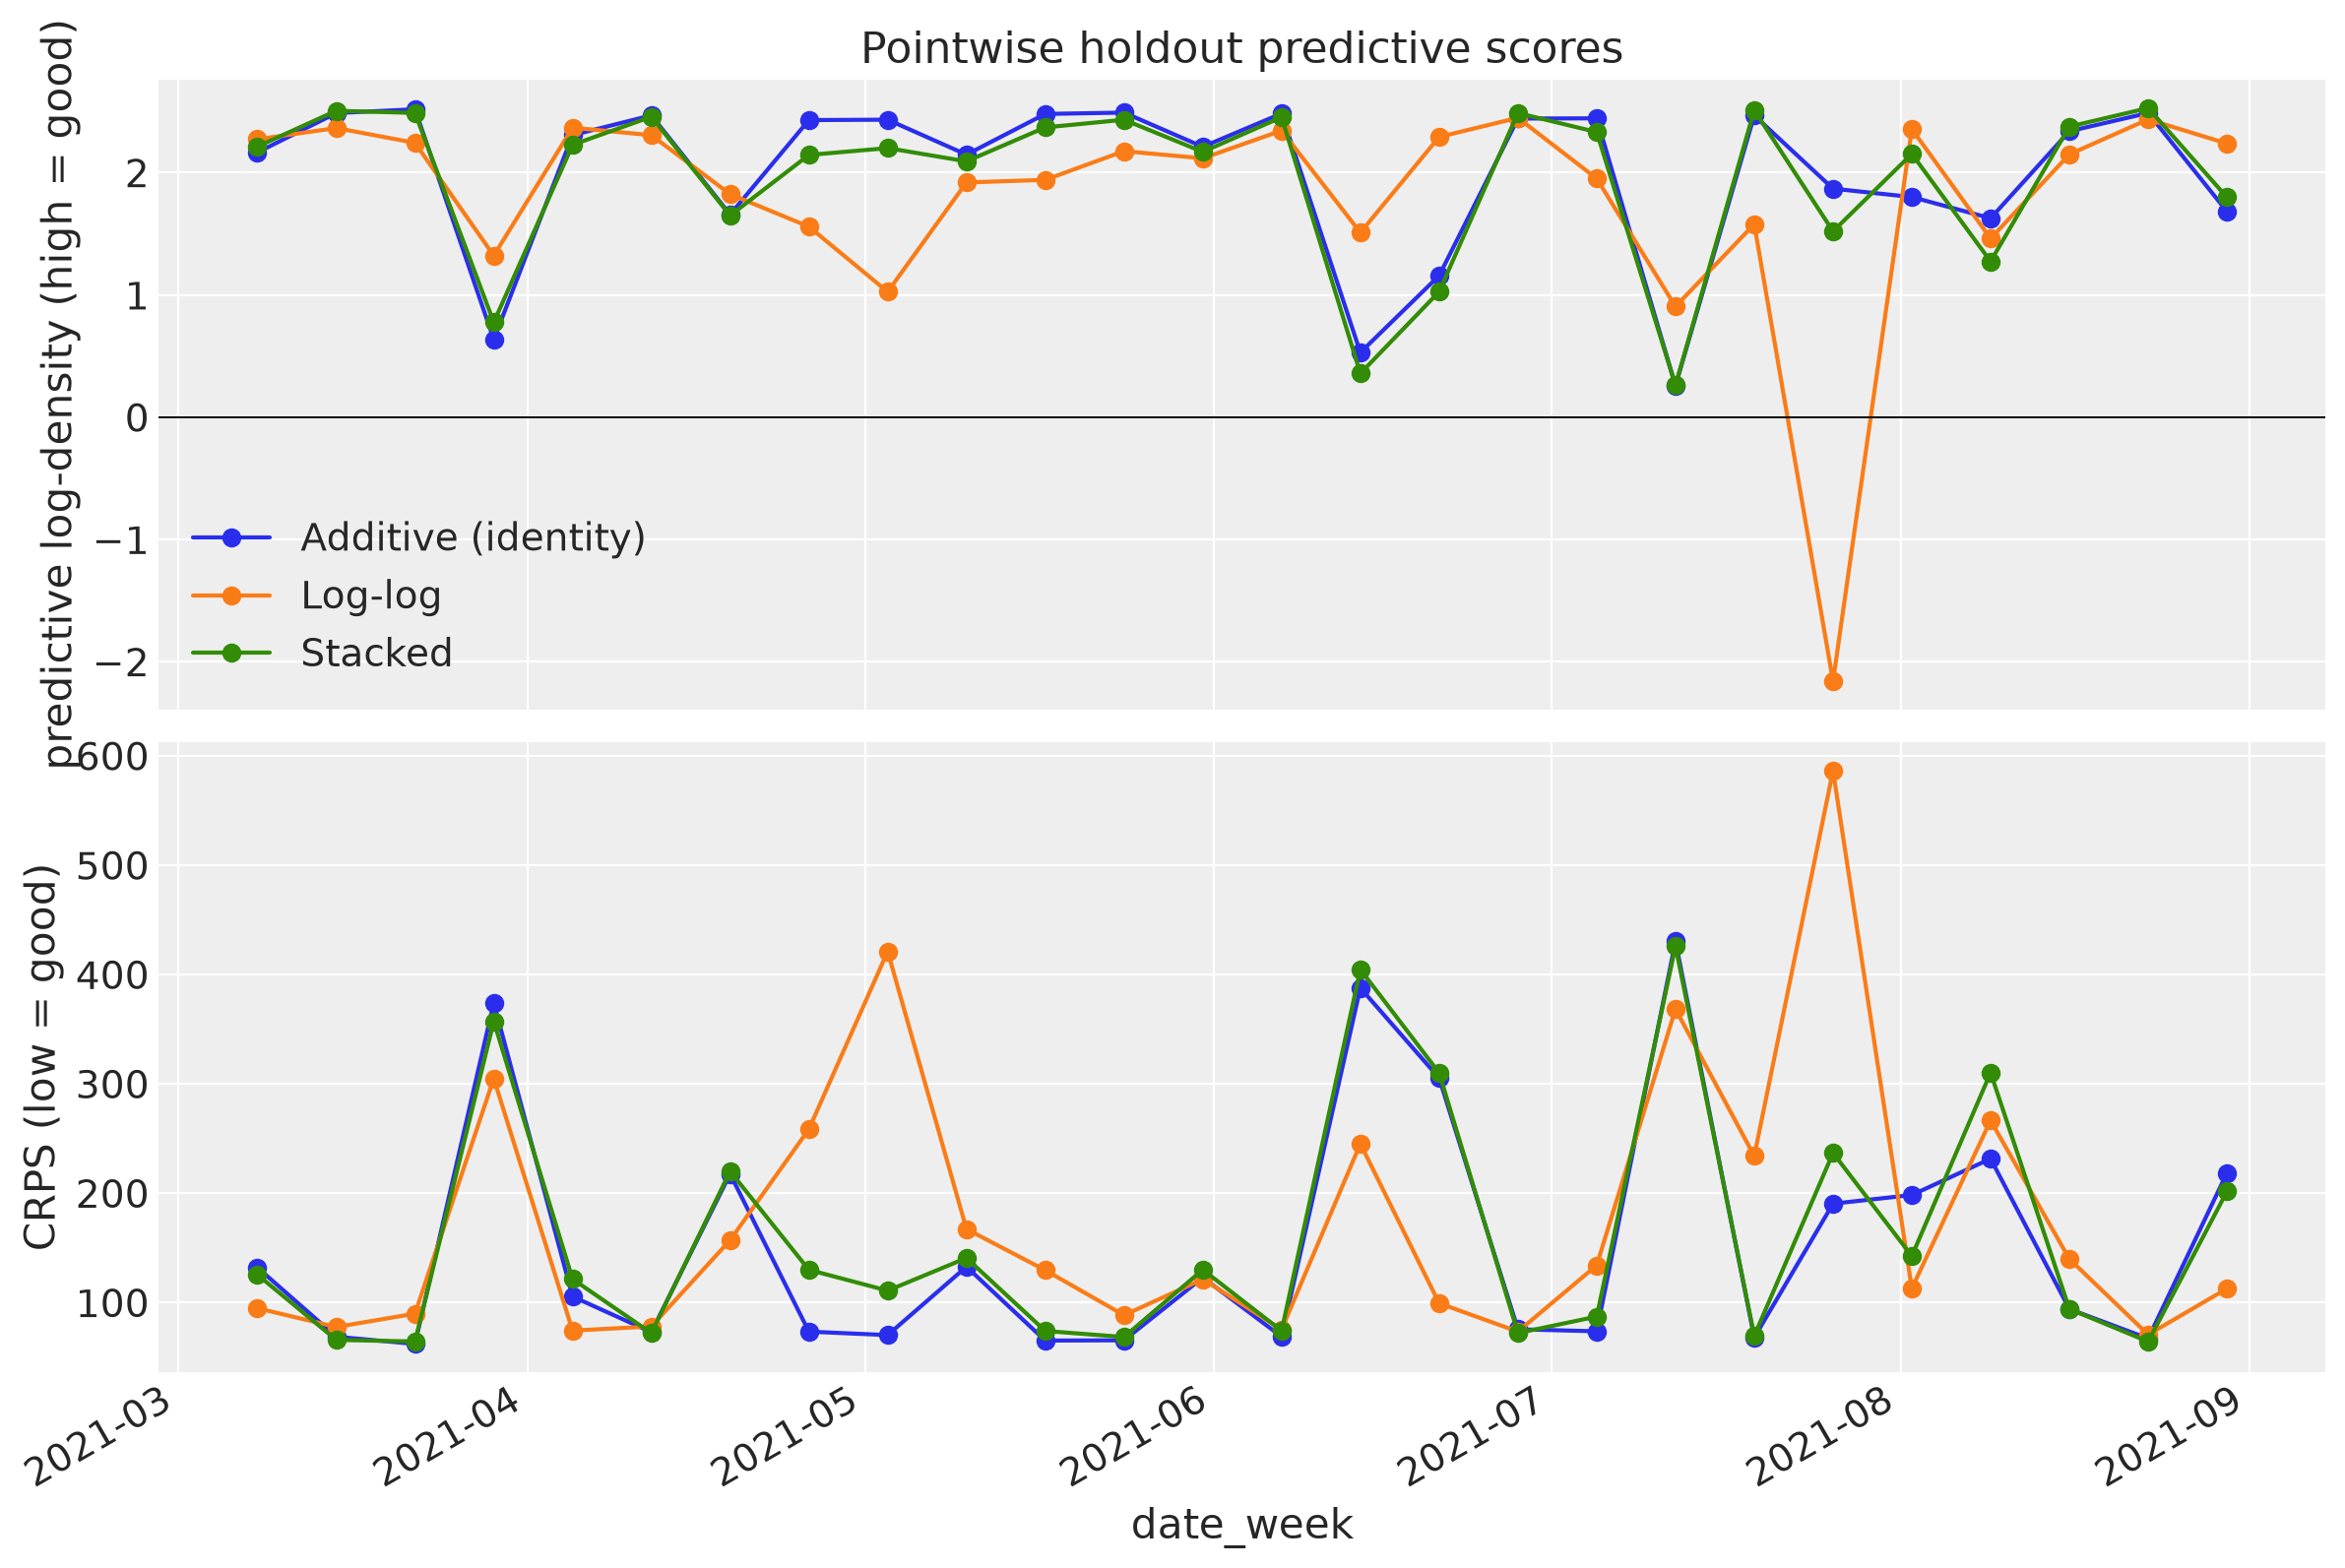

In [54]:
display(holdout_summary)

fig, (ax_log, ax_crps) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for model, group in holdout_scores.query(
    "model == 'Additive (identity)' | model == 'Log-log' | model == 'Stacked'").groupby("model", sort=False):
    ax_log.plot(group["date"], group["log_score"], marker="o", label=model)
    ax_crps.plot(group["date"], group["crps_sales"], marker="o", label=model)
ax_log.axhline(0, color="black", linewidth=0.7)
ax_log.set_ylabel("predictive log-density (high = good)")
ax_log.set_title("Pointwise holdout predictive scores")
ax_crps.set_ylabel("CRPS (low = good)")
ax_crps.set_xlabel(DATE_COLUMN)
ax_log.legend()
fig.autofmt_xdate()
fig.tight_layout()

## ROAS estimates across model assumptions

Predictive comparison tells us which model gives better future sales densities, but decision makers often
also want to understand how the modeling assumptions affect business quantities such as return on ad spend
(ROAS). The next plot compares in-sample all-time ROAS estimates for each candidate model and for the
stacked predictive mixture.

These ROAS summaries should be read as model-implied quantities conditional on each specification. The
stacked row is a weight-resampled mixture of model-implied ROAS distributions using prediction-optimal
stacking weights; it is not a separate causal model and carries no claim of ROAS optimality. Under log-link
models, unilateral channel increments are also not additive in the same way as in an identity-link model, so
the ROAS comparison is best read as a sensitivity analysis across assumptions rather than proof of causal
superiority. Predictive ELPD and causal ROAS answer different questions: a better predictive score does not
by itself establish that a channel caused the attributed sales or that its ROAS estimate is causally valid.

**Figure description.** The ROAS plot compares posterior distributions implied by each candidate
specification and the stacked predictive mixture. Differences show sensitivity to modeling assumptions and
uncertainty; they are not a causal ranking of channels or models.


In [17]:
def add_roas_to_predictions(mmm, idata):
    idata = idata.copy()
    roas = mmm.incrementality.compute_incremental_contribution(
        frequency="all_time"
    ) / mmm.idata["constant_data"]["channel_data"].sum("date")
    idata["posterior_predictive"] = idata["posterior_predictive"].assign(ROAS=roas)
    return idata


ordered_trees = [
    add_roas_to_predictions(reference_mmm_by_model[name], predictive_trees[name])
    for name in MODEL_NAMES
]
weights = np.array([weights_by_name[name] for name in MODEL_NAMES], dtype=float)
stacked_tree = weight_predictions(
    ordered_trees,
    weights=weights,
    group="posterior_predictive",
    random_seed=SEED,
)

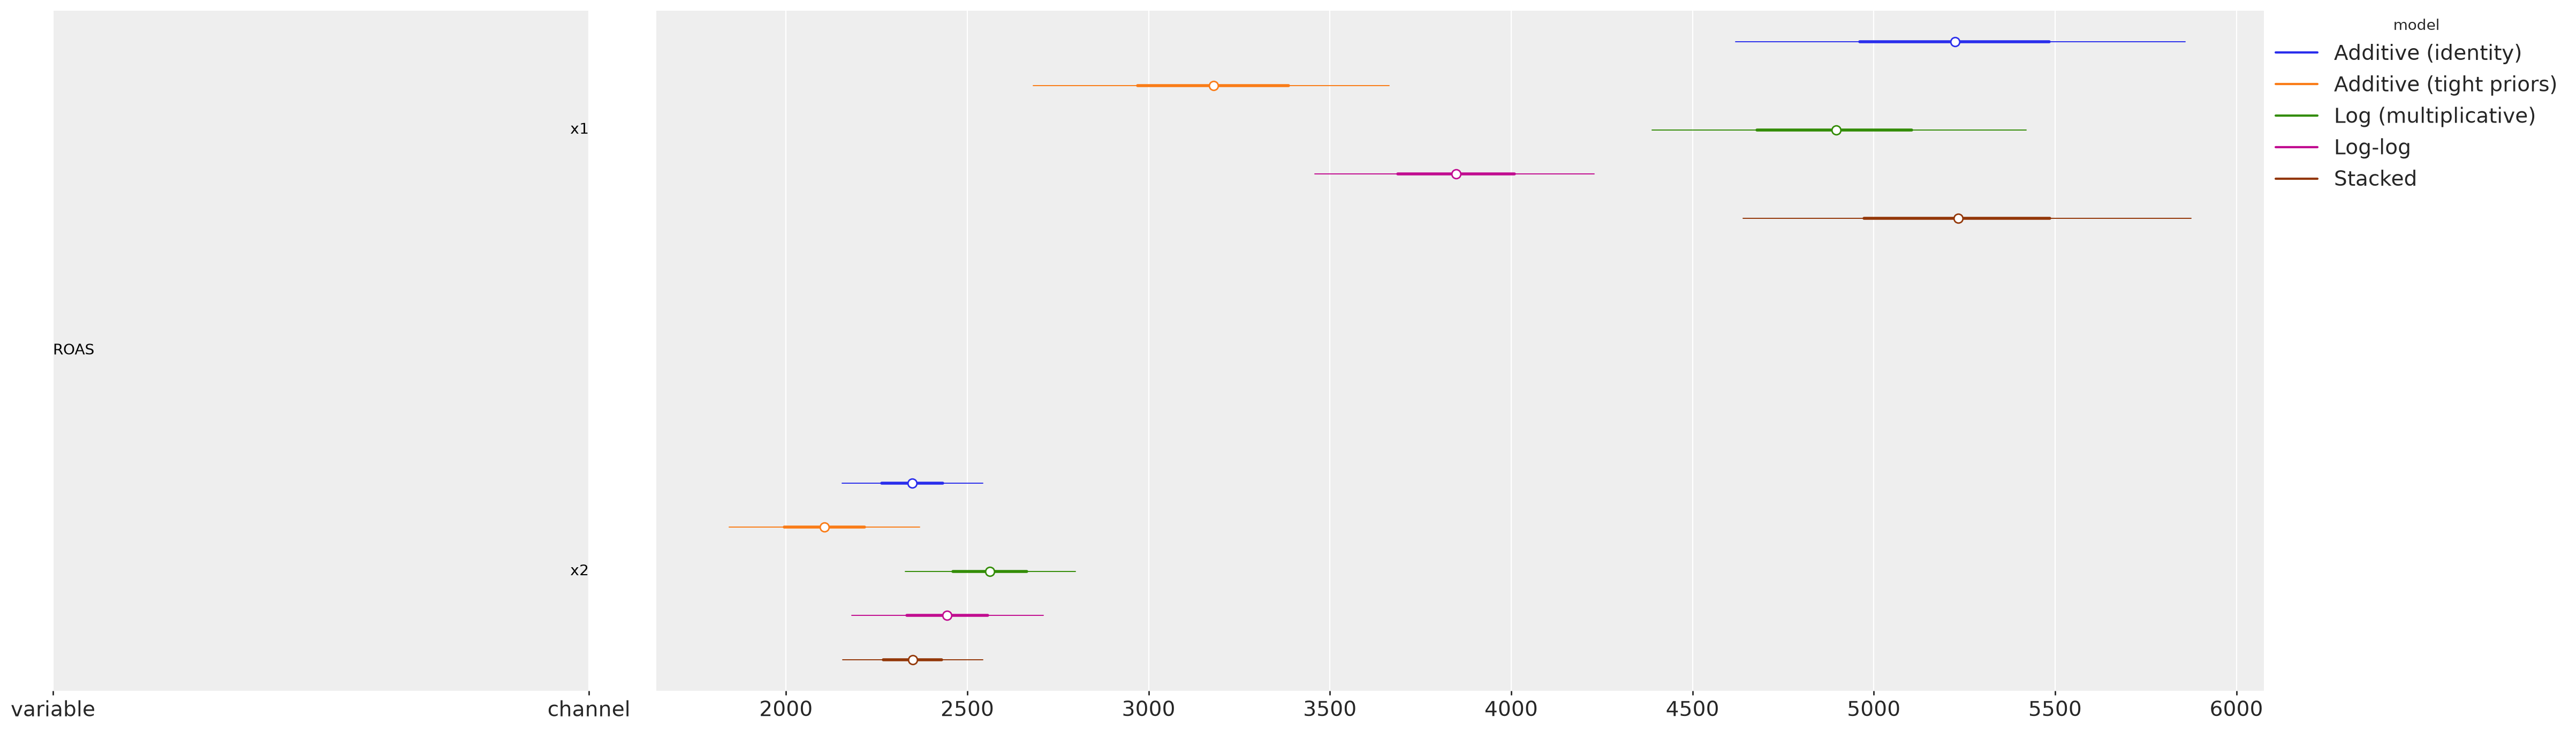

In [29]:
plot_num_samples = min(
    3999, stacked_tree["posterior_predictive"]["ROAS"].sizes["sample"]
)


def roas_tree_for_plot(tree, num_samples):
    roas_dataset = az.extract(
        tree,
        group="posterior_predictive",
        var_names=["ROAS"],
        keep_dataset=True,
        num_samples=num_samples,
    )["ROAS"].to_dataset(name="ROAS")
    roas_dataset = roas_dataset.assign_coords(
        sample=range(roas_dataset.sizes["sample"])
    )
    return xr.DataTree(children={"posterior_predictive": xr.DataTree(roas_dataset)})


def stacked_roas_tree_for_plot(tree, num_samples):
    roas = tree["posterior_predictive"]["ROAS"].isel(sample=slice(0, num_samples))
    roas_dataset = roas.to_dataset(name="ROAS").assign_coords(sample=range(num_samples))
    return xr.DataTree(children={"posterior_predictive": xr.DataTree(roas_dataset)})


roas_plot_trees = {
    **{
        MODEL_LABELS[name]: roas_tree_for_plot(tree, plot_num_samples)
        for name, tree in zip(MODEL_NAMES, ordered_trees, strict=True)
    },
    "Stacked": stacked_roas_tree_for_plot(stacked_tree, plot_num_samples),
}

pc = az.plot_forest(
    roas_plot_trees,
    var_names=["ROAS"],
    group="posterior_predictive",
    sample_dims=["sample"],
)
pc.add_legend(["model"])

## Key Takeaways for Bayesian Marketing Mix Model Validation

This case study uses LFO-CV to compare alternative MMM assumptions by the quantity we care about for
forecasting: one-week-ahead predictive density for sales. The comparison is leakage-aware because every
score is computed from models trained only on data available before the forecast origin, and the fixed
scaling constants keep priors and parameters on a comparable scale across expanding-window refits.

The results illustrate three useful points:

- PSIS-LFO-CV can turn a rolling-origin Bayesian model comparison into a much smaller number of exact
  refits, while still reporting Pareto-$k$ diagnostics for the approximation. The shipped exact pointwise
  artifact makes this calibration reproducible without rerunning those refits when its fingerprint matches.
- Single-model rankings should be read with their paired uncertainty. In this example, the holdout check is
  a noisy 26-week comparison and should be interpreted together with the LFO standard errors rather than as
  a definitive re-ranking.
- Stacking weights should be read as predictive-mixture weights. They can favor a lower-ranked individual
  model when that model contributes complementary predictions to the ensemble.

### A practical decision framework

1. **Screen with approximate LFO-CV.** Compare pointwise and aggregate ELPD on the forecast task that
   matters, using common origins and fixed scaling.
2. **Check reliability.** Inspect Pareto-$k$, refit frequency, and empirical approximate-versus-exact error
   rather than treating a score ranking as sufficient.
3. **Use exact refits when needed.** Let the configured diagnostic trigger exact computation, and
   investigate material retrospective approximation errors or regime changes with exact refits before
   relying on a close ranking.
4. **Choose or combine cautiously.** Select one model only when its predictive advantage and uncertainty
   support that decision; use stacking when candidate predictions are complementary. Neither outcome
   establishes causal ROAS.
5. **Validate the horizon.** Use the separate longer holdout to ask whether the LFO pattern persists after
   the run, while recognizing that agreement or disagreement can reflect horizon and regime differences.

The ROAS comparison then shows how business-facing summaries can vary across plausible model assumptions.
These summaries are model-implied sensitivity checks: they help us understand the implications of each
specification, while the LFO-CV scores tell us which assumptions are more useful for predicting future sales
in this dataset.

## FAQ

**What is LFO-CV?** Leave-future-out cross-validation evaluates future observations by moving a time-ordered
forecast origin forward. PSIS can update a fitted posterior between origins, with exact refits when
diagnostics indicate that the approximation is not reliable.

**How is LFO-CV different from ordinary cross-validation?** It preserves temporal order: training uses the
past and scoring uses the future. Randomly mixing observations, or using future information in scaling,
would answer a different question and can leak information.

**What does Pareto-$k$ mean?** It summarizes the tail behavior of the importance ratios used by PSIS. Larger
values signal heavier tails and greater approximation risk; here `K_THRESHOLD = 0.5` is the configured
automatic refit trigger, not a universal quality guarantee.

**When are exact refits needed?** Use them when the automatic diagnostic triggers, when empirical
approximate-versus-exact error is material, or when a close model decision depends on a potentially
unreliable PSIS update. Exact refits are a reliability fallback, not a promise that one model is causally
correct.

**What does pointwise ELPD measure?** It is the log predictive density assigned to one held-out future
observation or forecast origin. Aggregate ELPD sums those contributions over the common origins; neither
quantity alone establishes causal attribution or ROAS.

**Related PyMC-Marketing documentation:** {doc}`MMM fundamentals </guide/mmm/mmm_intro>`, {ref}`additive,
multiplicative, and log-log MMMs <mmm_multiplicative>`, {ref}`model evaluation <mmm_evaluation>`,
{ref}`budget optimization <mmm_budget_allocation_example>`, and {ref}`ROAS analysis <mmm_roas>`.

## References

- Bürkner, P.-C., Gabry, J., & Vehtari, A. (2020). [Approximate leave-future-out cross-validation for
  Bayesian time series models][lfo-paper]. *Journal of Statistical Computation and Simulation*.
- Vehtari, A., Simpson, D., Gelman, A., Yao, Y., & Gabry, J. (2024). [Pareto smoothed importance
  sampling][psis-paper]. *Journal of Machine Learning Research*.
- [Stan loo guide to leave-future-out cross-validation][stan-loo].
- PyMC-Marketing documentation: {ref}`mmm_multiplicative`.

[lfo-paper]: https://www.tandfonline.com/doi/full/10.1080/00949655.2020.1783262
[psis-paper]: https://jmlr.org/papers/v25/19-556.html
[stan-loo]: https://mc-stan.org/loo/articles/loo2-lfo.html


In [19]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Sat, 26 Sep 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4

IPython       : 9.15.0
arviz         : 1.2.0
arviz_base    : 1.2.0
arviz_stats   : 1.4.0.dev0
json          : 2.0.9
logging       : 0.5.1.2
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
scipy         : 1.18.0
xarray        : 2026.4.0

Watermark: 2.6.0

